# Unsupervised Learning: Trade & Ahead

## Problem Statement

### Context

The stock market has consistently proven to be a good place to invest in and save for the future. There are a lot of compelling reasons to invest in stocks. It can help in fighting inflation, create wealth, and also provides some tax benefits. Good steady returns on investments over a long period of time can also grow a lot more than seems possible. Also, thanks to the power of compound interest, the earlier one starts investing, the larger the corpus one can have for retirement. Overall, investing in stocks can help meet life's financial aspirations.

It is important to maintain a diversified portfolio when investing in stocks in order to maximise earnings under any market condition. Having a diversified portfolio tends to yield higher returns and face lower risk by tempering potential losses when the market is down. It is often easy to get lost in a sea of financial metrics to analyze while determining the worth of a stock, and doing the same for a multitude of stocks to identify the right picks for an individual can be a tedious task. By doing a cluster analysis, one can identify stocks that exhibit similar characteristics and ones which exhibit minimum correlation. This will help investors better analyze stocks across different market segments and help protect against risks that could make the portfolio vulnerable to losses.


### Objective

Trade&Ahead is a financial consultancy firm who provide their customers with personalized investment strategies. They have hired you as a Data Scientist and provided you with data comprising stock price and some financial indicators for a few companies listed under the New York Stock Exchange. They have assigned you the tasks of analyzing the data, grouping the stocks based on the attributes provided, and sharing insights about the characteristics of each group.

### Data Dictionary

- Ticker Symbol: An abbreviation used to uniquely identify publicly traded shares of a particular stock on a particular stock market
- Company: Name of the company
- GICS Sector: The specific economic sector assigned to a company by the Global Industry Classification Standard (GICS) that best defines its business operations
- GICS Sub Industry: The specific sub-industry group assigned to a company by the Global Industry Classification Standard (GICS) that best defines its business operations
- Current Price: Current stock price in dollars
- Price Change: Percentage change in the stock price in 13 weeks
- Volatility: Standard deviation of the stock price over the past 13 weeks
- ROE: A measure of financial performance calculated by dividing net income by shareholders' equity (shareholders' equity is equal to a company's assets minus its debt)
- Cash Ratio: The ratio of a  company's total reserves of cash and cash equivalents to its total current liabilities
- Net Cash Flow: The difference between a company's cash inflows and outflows (in dollars)
- Net Income: Revenues minus expenses, interest, and taxes (in dollars)
- Earnings Per Share: Company's net profit divided by the number of common shares it has outstanding (in dollars)
- Estimated Shares Outstanding: Company's stock currently held by all its shareholders
- P/E Ratio: Ratio of the company's current stock price to the earnings per share
- P/B Ratio: Ratio of the company's stock price per share by its book value per share (book value of a company is the net difference between that company's total assets and total liabilities)

## Importing necessary libraries and data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to compute distances
from scipy.spatial.distance import cdist

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# to visualize the elbow curve and silhouette scores
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

In [ ]:
data= pd.read_csv('/content/drive/MyDrive/stock_data.csv')

## Data Overview



###View data

In [ ]:
#Look at first 5 rows of the data
data.head()

,Ticker Symbol,Security,GICS Sector,GICS Sub Industry,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio
0,AAL,American Airlines Group,Industrials,Airlines,42.349998,9.999995,1.687151,135,51,-604000000,7610000000,11.39,6.681299e+08,3.718174,-8.784219
1,ABBV,AbbVie,Health Care,Pharmaceuticals,59.240002,8.339433,2.197887,130,77,51000000,5144000000,3.15,1.633016e+09,18.806350,-8.750068
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,44.910000,11.301121,1.273646,21,67,938000000,4423000000,2.94,1.504422e+09,15.275510,-0.394171
3,ADBE,Adobe Systems Inc,Information Technology,Application Software,93.940002,13.977195,1.357679,9,180,-240840000,629551000,1.26,4.996437e+08,74.555557,4.199651
4,ADI,"Analog Devices, Inc.",Information Technology,Semiconductors,55.320000,-1.827858,1.701169,14,272,315120000,696878000,0.31,2.247994e+09,178.451613,1.059810


In [ ]:
#Look at the 5 last rows of the data
data.tail()


,Ticker Symbol,Security,GICS Sector,GICS Sub Industry,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio
335,YHOO,Yahoo Inc.,Information Technology,Internet Software & Services,33.259998,14.887727,1.845149,15,459,-1032187000,-4359082000,-4.64,939457327.6,28.976191,6.261775
336,YUM,Yum! Brands Inc,Consumer Discretionary,Restaurants,52.516175,-8.698917,1.478877,142,27,159000000,1293000000,2.97,435353535.4,17.682214,-3.838260
337,ZBH,Zimmer Biomet Holdings,Health Care,Health Care Equipment,102.589996,9.347683,1.404206,1,100,376000000,147000000,0.78,188461538.5,131.525636,-23.884449
338,ZION,Zions Bancorp,Financials,Regional Banks,27.299999,-1.158588,1.468176,4,99,-43623000,309471000,1.20,257892500.0,22.749999,-0.063096
339,ZTS,Zoetis,Health Care,Pharmaceuticals,47.919998,16.678836,1.610285,32,65,272000000,339000000,0.68,498529411.8,70.470585,1.723068


###Shape of the data

In [ ]:
#Shape of the data
data.shape

(340, 15)

- There are 15 columns and 340 rows, not a very large dataset.

###View data types

In [ ]:
#View the datatypes of numerical and non-numerical data
data.dtypes



,0
Ticker Symbol,object
Security,object
GICS Sector,object
GICS Sub Industry,object
Current Price,float64
Price Change,float64
Volatility,float64
ROE,int64
Cash Ratio,int64
Net Cash Flow,int64


- Most of the data is numerical, 4 columns are objects

###Make copy of the data

In [ ]:
#Copy data
df=data.copy()


###Assess for unique data columns

In [ ]:
#Assess whether the Ticker symbol column are unique identifiers
df['Ticker Symbol'].is_unique

True

In [ ]:
# Assess whether the Security column are unique identifiers
df['Security'].is_unique


True

In [ ]:
# Asess whether GICS Sector and GICS subindustry have unique identifiers
print(df['GICS Sector'].is_unique)
print(df['GICS Sub Industry'].is_unique)

False
False


- Ticker Symbol can be dropped

In [ ]:
#Drop Ticker Symbol column
df.drop('Ticker Symbol', axis=1, inplace=True)

###Remove duplicate entries

In [ ]:
#Look for duplicates
df.duplicated().sum()

np.int64(0)

- There are no duplicates

###Look for missing values

In [ ]:
# Missing values
df.isnull().sum()

,0
Security,0
GICS Sector,0
GICS Sub Industry,0
Current Price,0
Price Change,0
Volatility,0
ROE,0
Cash Ratio,0
Net Cash Flow,0
Net Income,0


- There are no missing values

###View statistics

In [ ]:
df.describe()

,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio
count,340.000000,340.000000,340.000000,340.000000,340.000000,3.400000e+02,3.400000e+02,340.000000,3.400000e+02,340.000000,340.000000
mean,80.862345,4.078194,1.525976,39.597059,70.023529,5.553762e+07,1.494385e+09,2.776662,5.770283e+08,32.612563,-1.718249
std,98.055086,12.006338,0.591798,96.547538,90.421331,1.946365e+09,3.940150e+09,6.587779,8.458496e+08,44.348731,13.966912
min,4.500000,-47.129693,0.733163,1.000000,0.000000,-1.120800e+10,-2.352800e+10,-61.200000,2.767216e+07,2.935451,-76.119077
25%,38.555000,-0.939484,1.134878,9.750000,18.000000,-1.939065e+08,3.523012e+08,1.557500,1.588482e+08,15.044653,-4.352056
50%,59.705000,4.819505,1.385593,15.000000,47.000000,2.098000e+06,7.073360e+08,2.895000,3.096751e+08,20.819876,-1.067170
75%,92.880001,10.695493,1.695549,27.000000,99.000000,1.698108e+08,1.899000e+09,4.620000,5.731175e+08,31.764755,3.917066
max,1274.949951,55.051683,4.580042,917.000000,958.000000,2.076400e+10,2.444200e+10,50.090000,6.159292e+09,528.039074,129.064585


- The average Current Price is 80 dollors. The range is wide from 4.5 to 1275 dollors.
- The average Price Change is $4.

   The range is from -47 to 55 dollors.
- The volatility is 1.5  with a range from 0.7-4.6.
- ROE ranges from 1% to 917%, with a median of 15%.
- The median cash ratio is 47, but the range is 0 to 958 dollors.
- Net income ranges from 23.5 to 24.4 billion dollors, showing both highly profitable companies and those with significant losses.
- The average P/E ratio is quite high at 32.61, suggesting many stocks may be priced at a premium, though the wide standard deviation (44.35) indicates varying valuations.
-The average P/B ratio is negative (-1.72), which is unusual and suggests some companies may have negative book values, possibly due to accumulated losses.


## Exploratory Data Analysis (EDA)



###Univariate analysis

In [ ]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

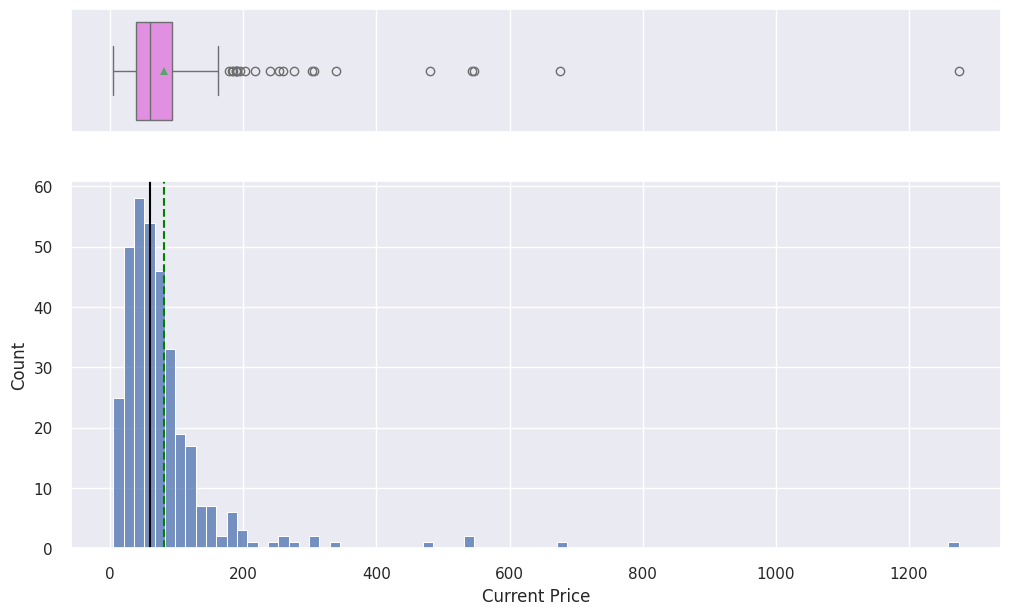

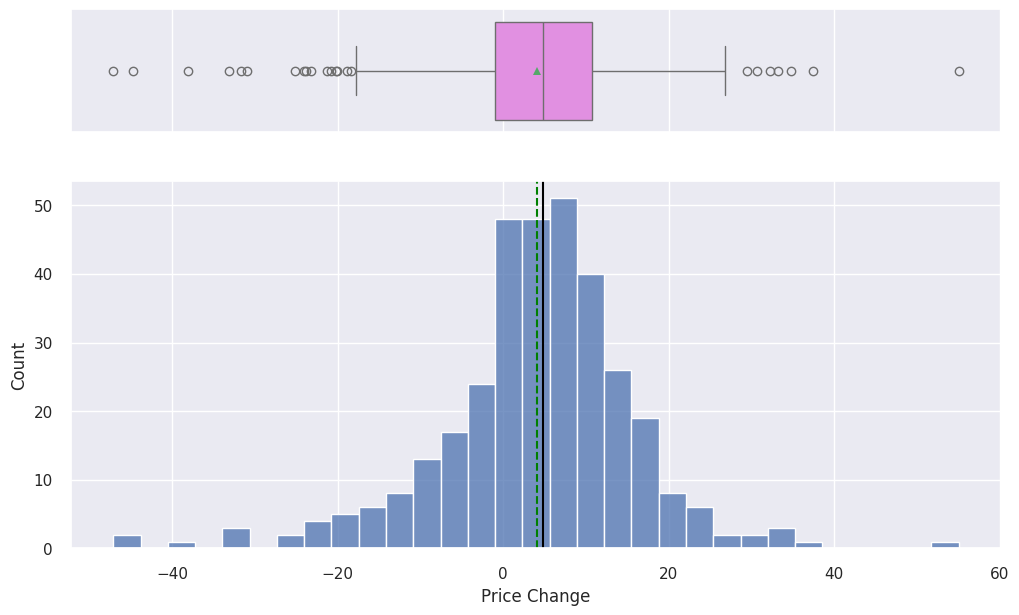

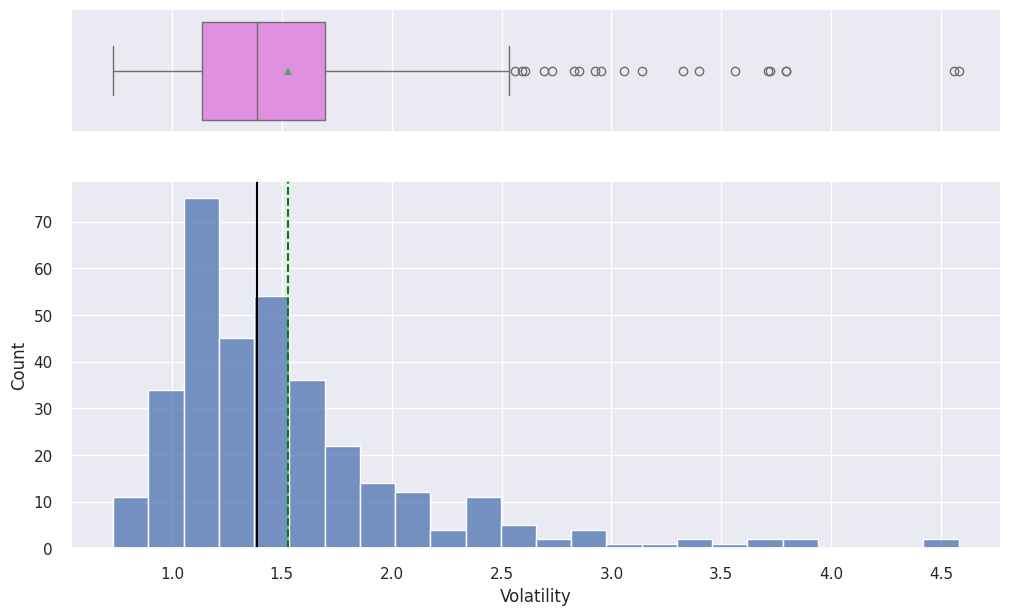

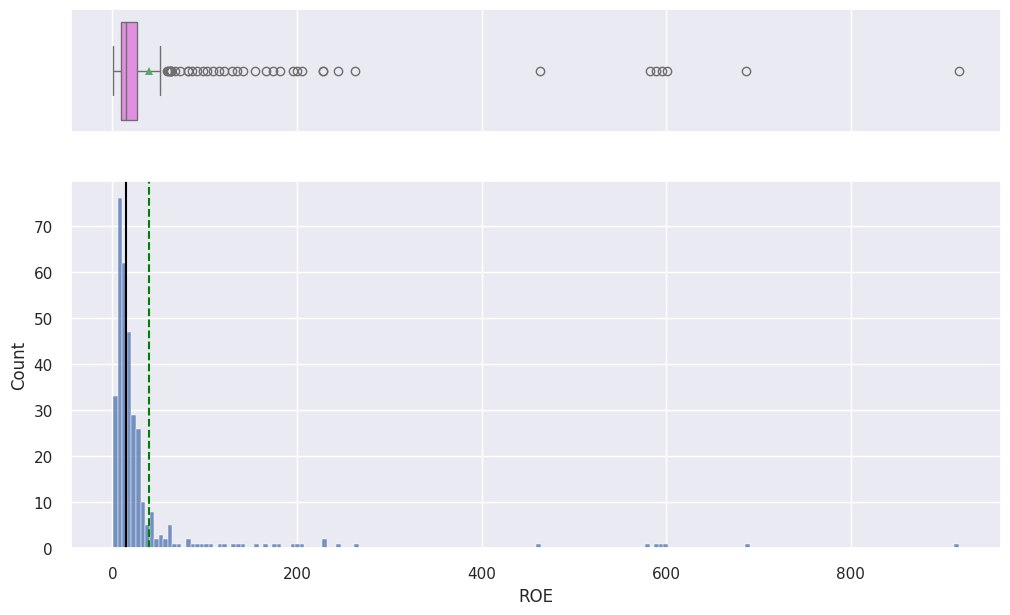

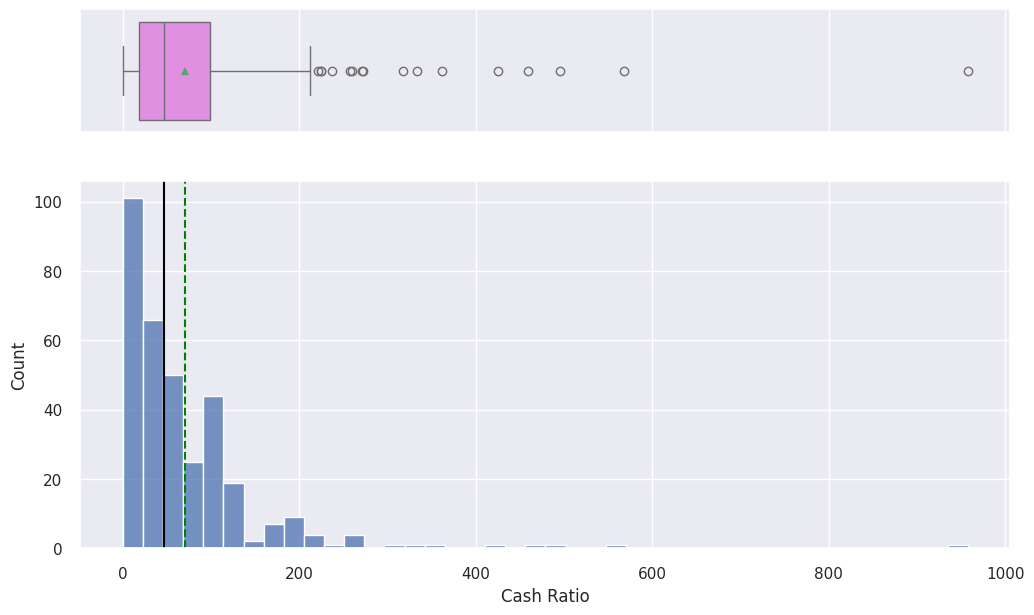

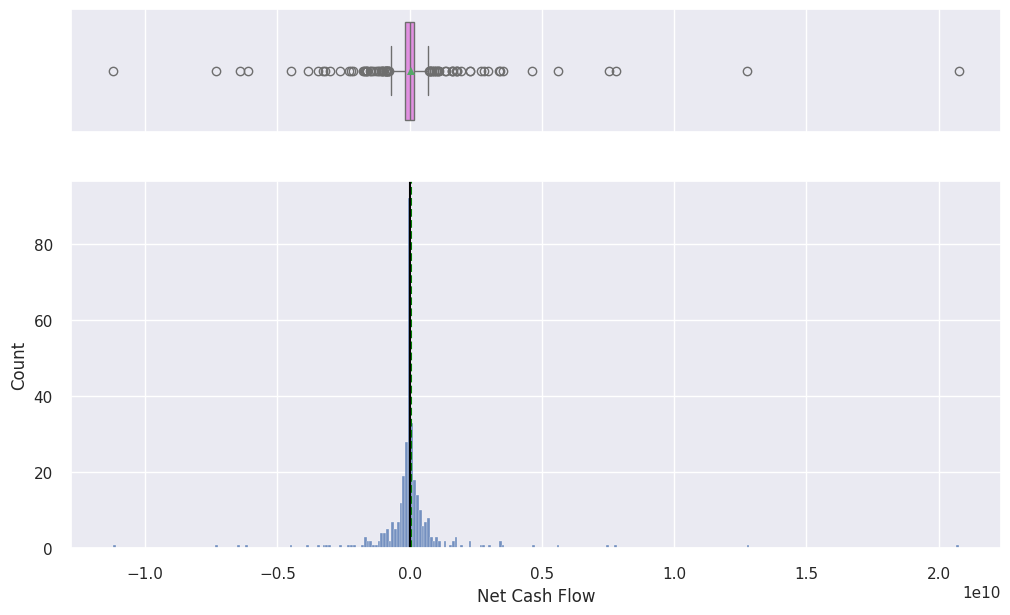

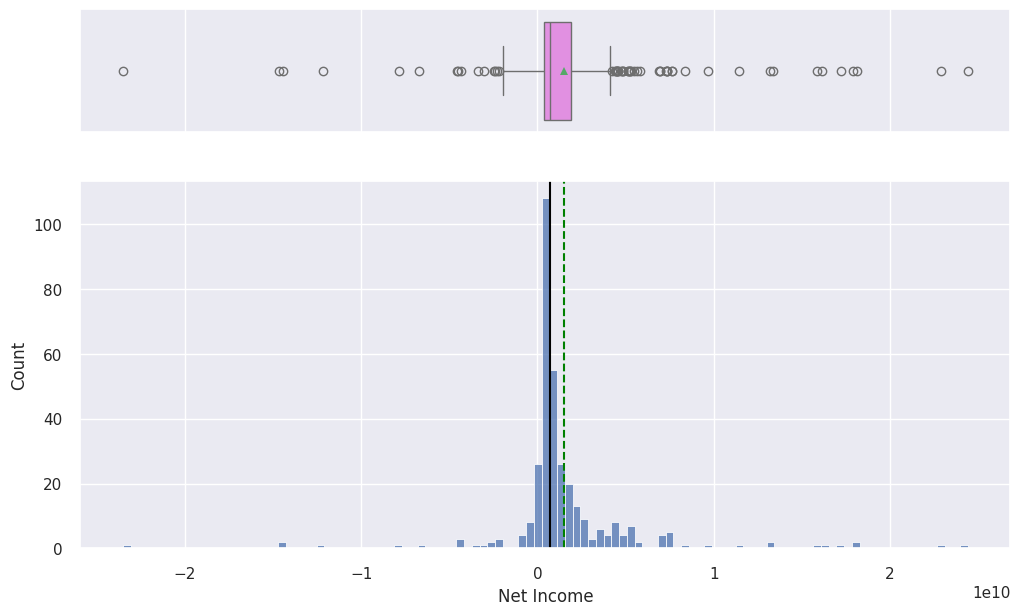

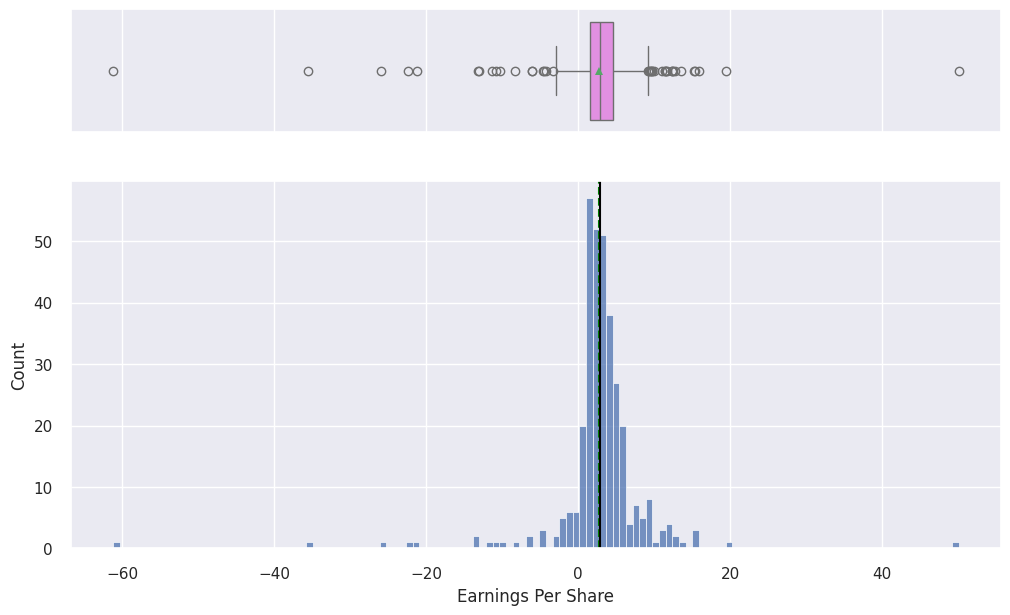

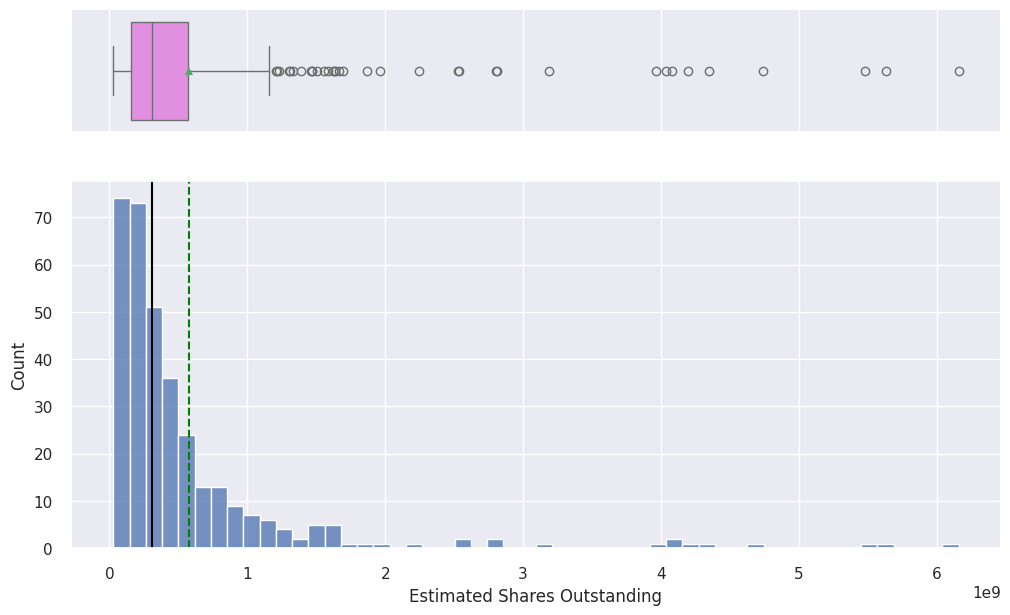

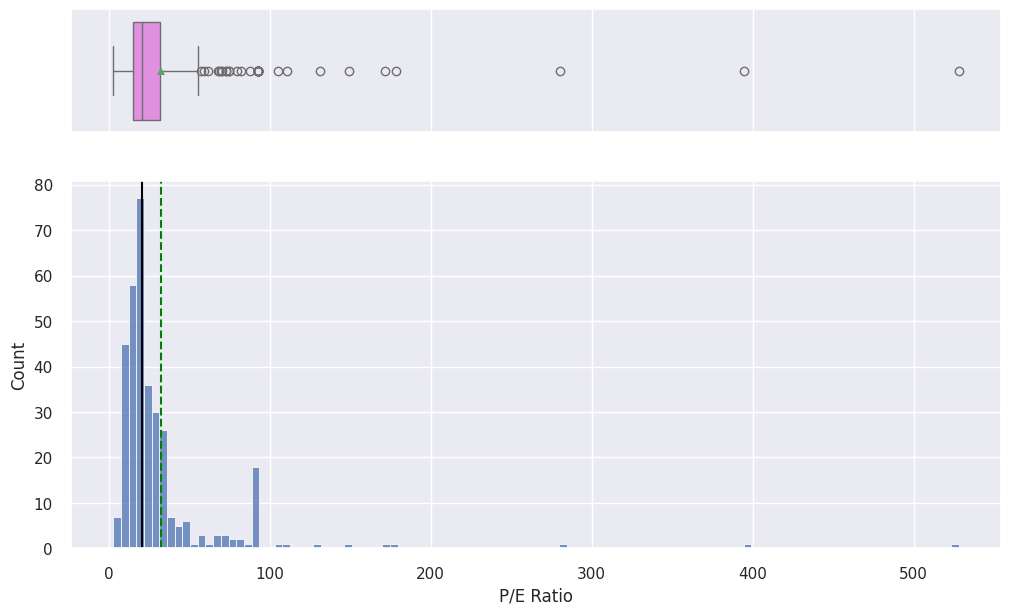

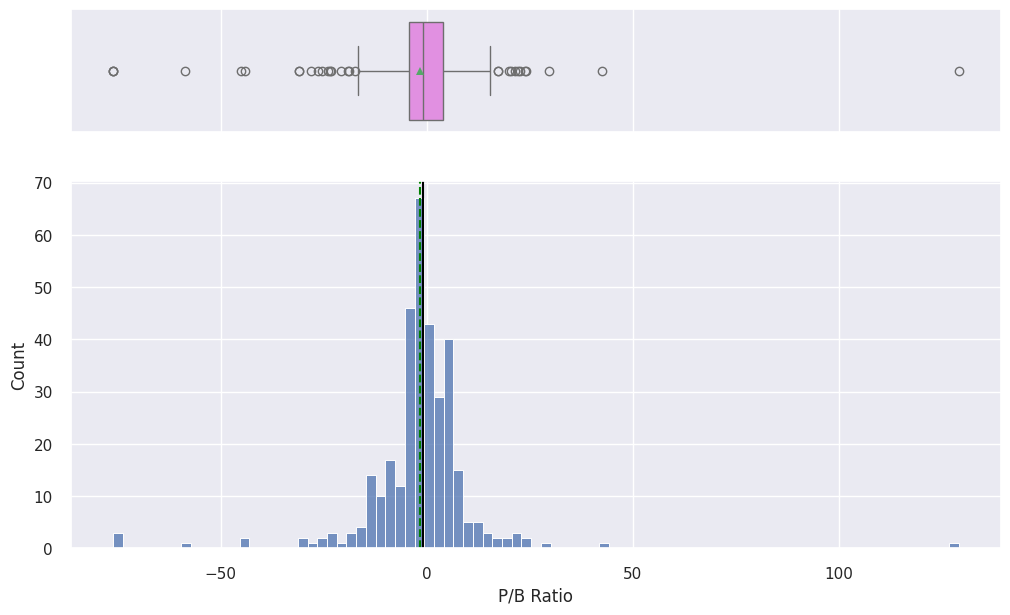

In [ ]:
# selecting numerical columns
num_col = df.select_dtypes(include=np.number).columns.tolist()

for item in num_col:
    histogram_boxplot(df, item)

- Current Price is skewed to the right with a long right tail, due to very high priced ourliers.
- Price change is a normal distribution with morst shares showing modest gains.
-ROE is highly skewed to the right indicating that several companies have exceptional performance.
- Net cash fow, cash ratio and income distributions are highly skewed to the right, which is usual for financial metrics. This indicates that a small amount of companies have stronger financial position than the majority of companies.

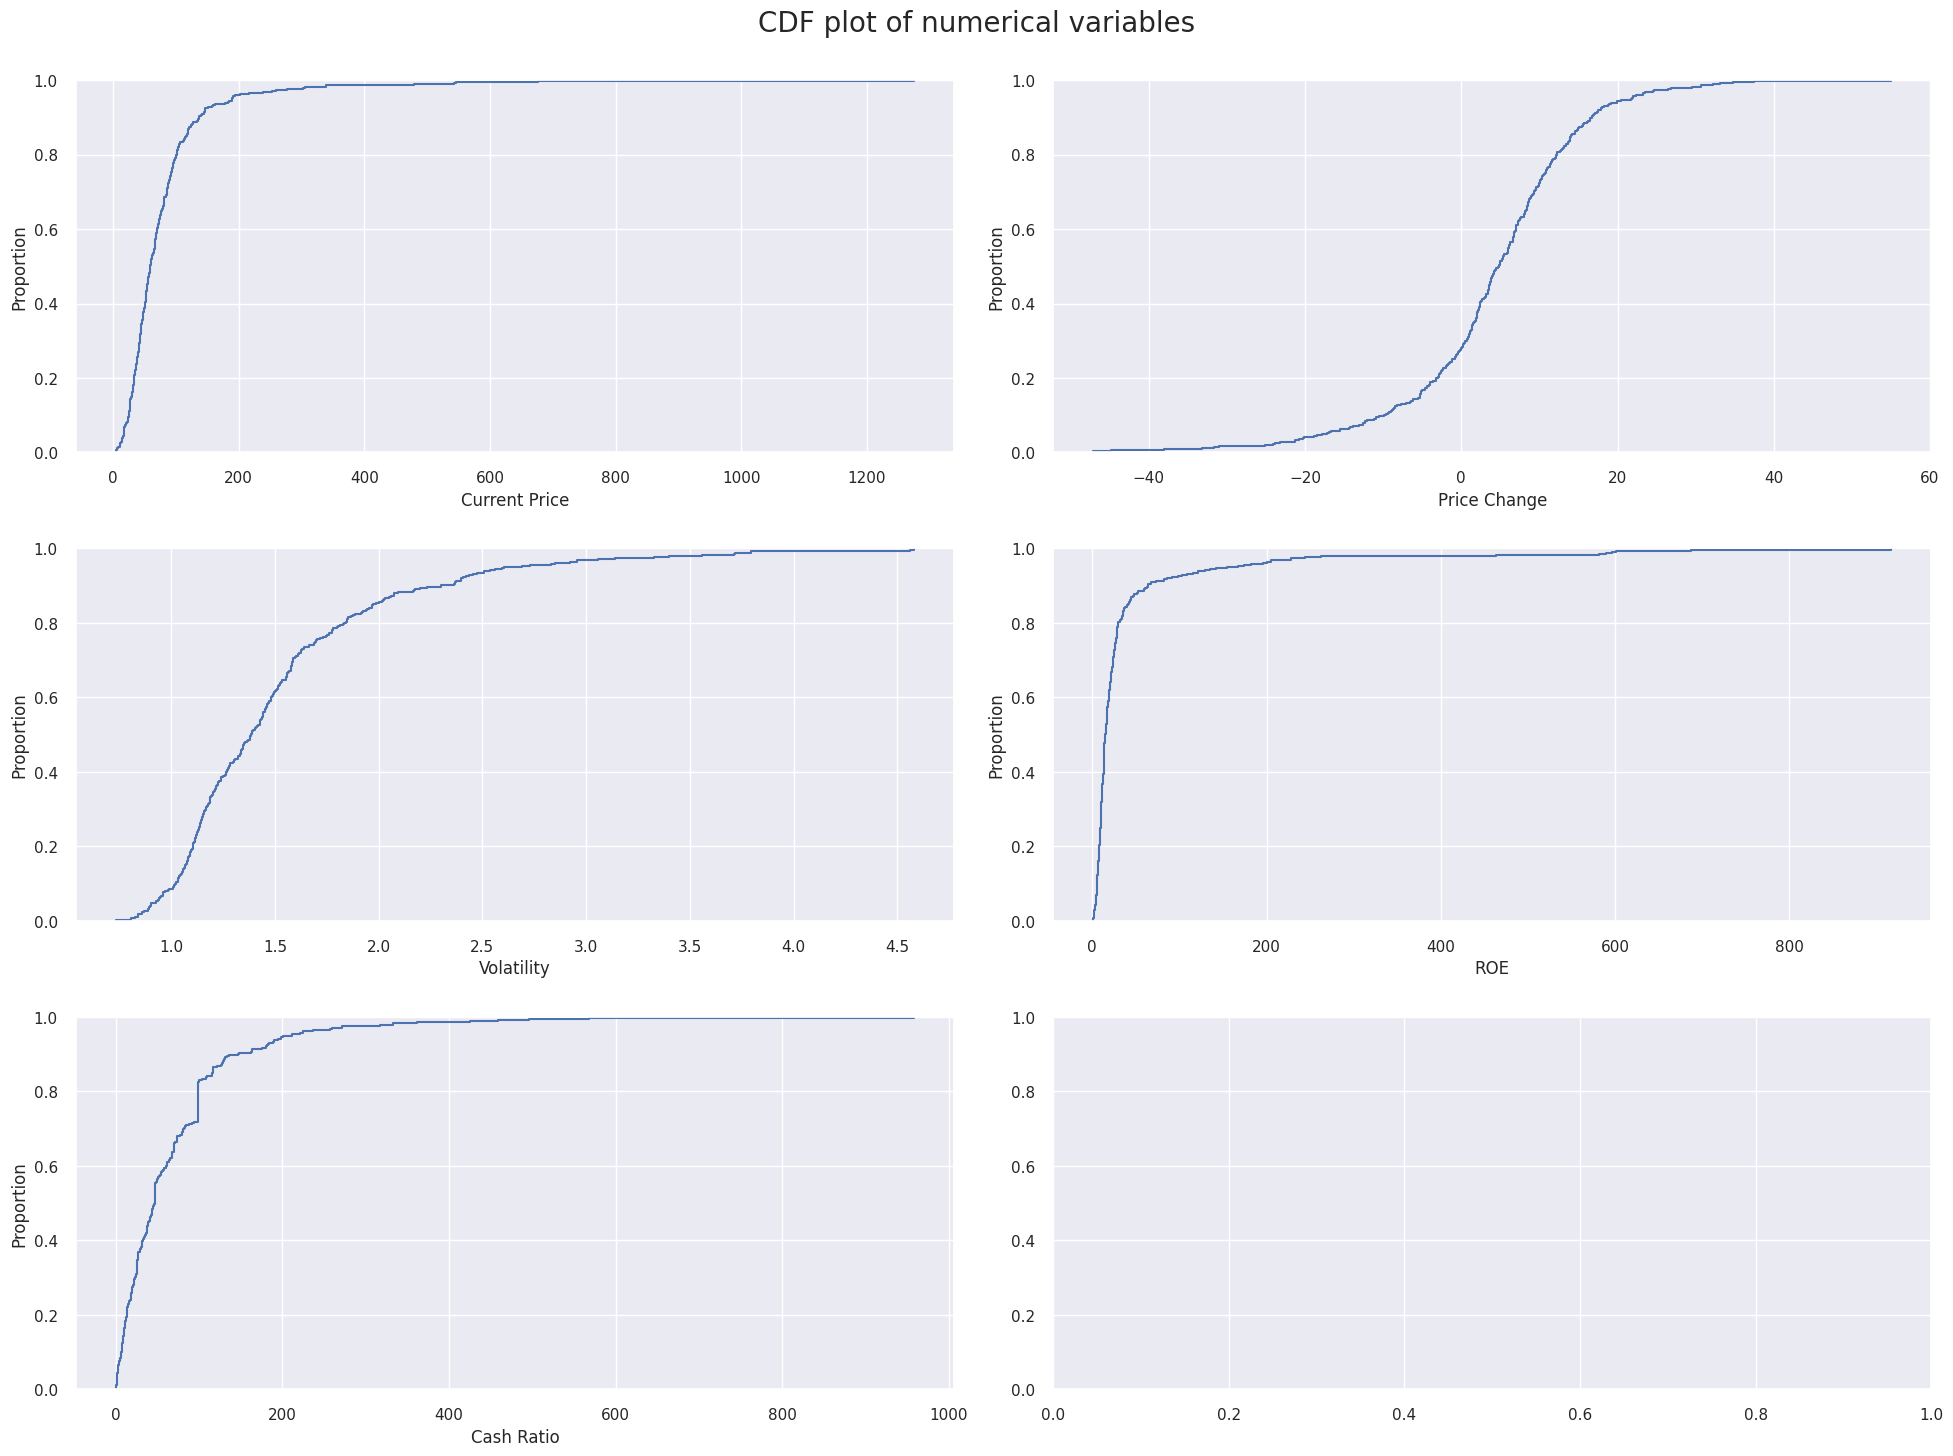

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(20, 15))
fig.suptitle("CDF plot of numerical variables", fontsize=20)
counter = 0
for ii in range(3):
    sns.ecdfplot(ax=axes[ii][0], x=df[num_col[counter]])
    counter = counter + 1
    if counter != 5:
        sns.ecdfplot(ax=axes[ii][1], x=df[num_col[counter]])
        counter = counter + 1
    else:
        pass

fig.tight_layout(pad=2.0)

- 80% have a current price under 100 dollors.
- 30% have a negative price change , and 70% have a positive price change.
- 60% of the volatility is under the mean of 1.5.
- 90% of ROE is under 50.
- 80% of the cash ratio is under 100.


In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

<ipython-input-156-61446a186199>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


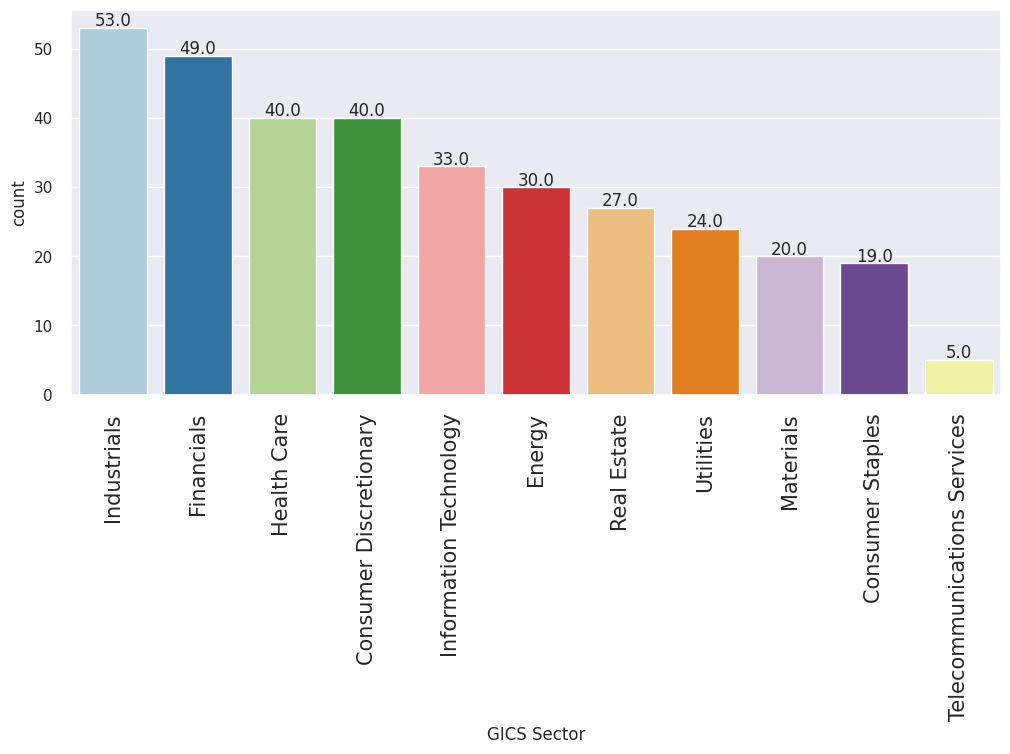

In [ ]:
# Visualise GIGS Sector as labeled barplot
labeled_barplot(df, "GICS Sector"),
plt.show()



- Industrials, Financials , Health Care and Consumer Discretionary are the most weighted economic sectors

<ipython-input-156-61446a186199>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


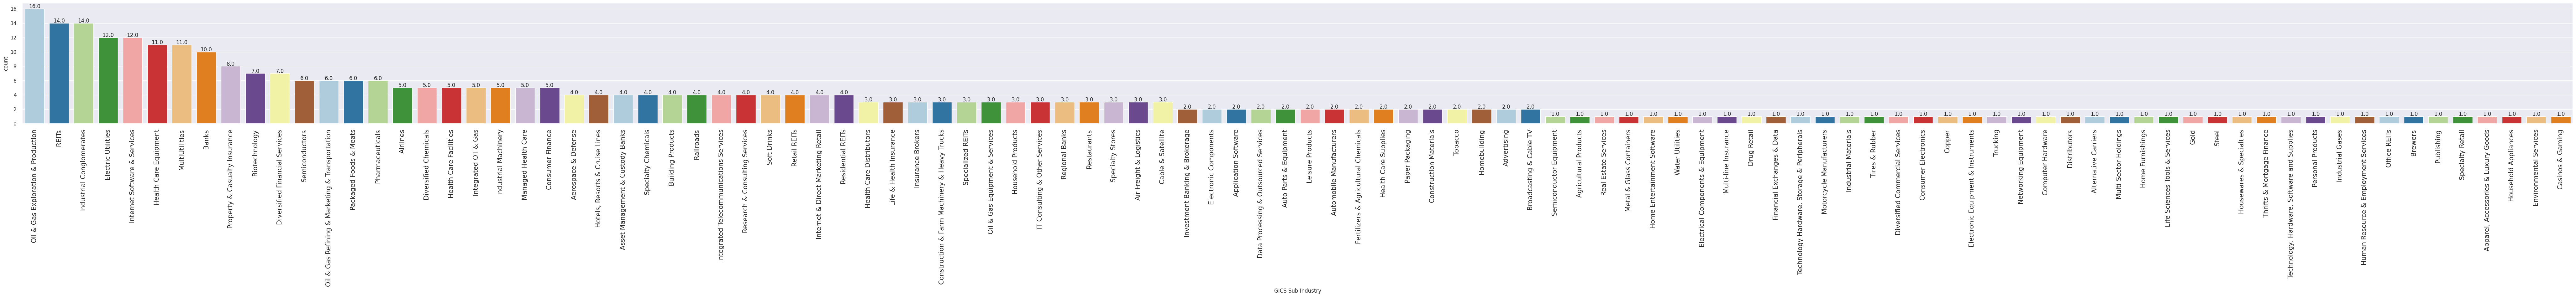

(None,)

In [ ]:
#Visualise GIGS Sub Industry as labeled barplot
labeled_barplot(df, "GICS Sub Industry"),

- Oil and Gas production, REITS, industrial Conglomerates, Electric Utilities and Internet Software and services are the top 5

###Bivariate analysis

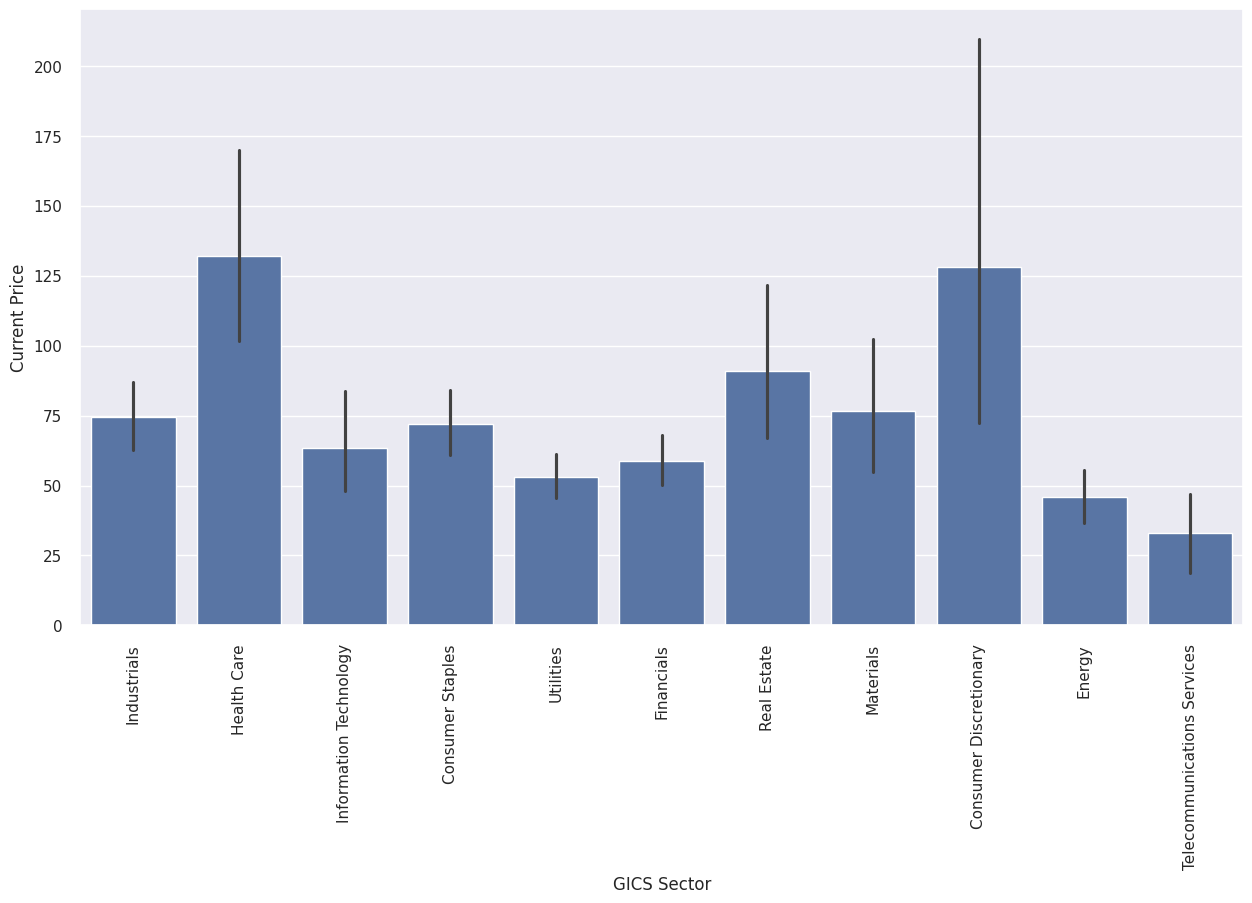

In [ ]:
#  Economic sector versus Price in barplot
plt.figure(figsize=(15, 8))
sns.barplot(x="GICS Sector", y="Current Price", data=df)
plt.xticks(rotation=90)
plt.show()





- The highest mean price is in the health care (130 dollors),
- Consumer Discretionary mean price (127 dollors)and
- Real estate mean price (90 dollors).

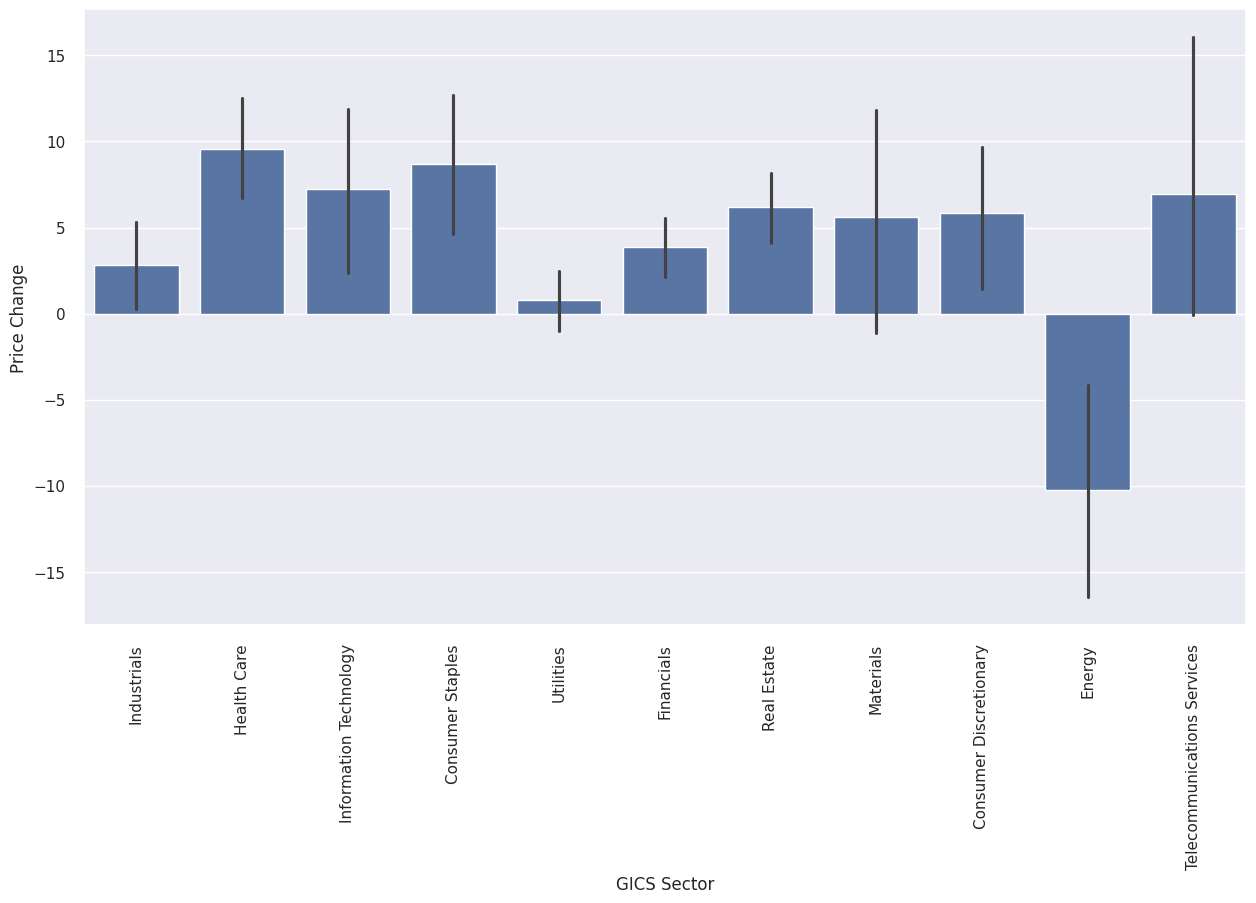

In [ ]:
#Price change vs economic sector
plt.figure(figsize=(15, 8))
sns.barplot(x="GICS Sector", y="Price Change", data=df)
plt.xticks(rotation=90)
plt.show()


- The maximum mean price change was - 10 in the Energy Sector
- The next positive change mean was 9 in the Health care Sector
- Consumer staples positive change mean was 7 in the Consumers staples sector

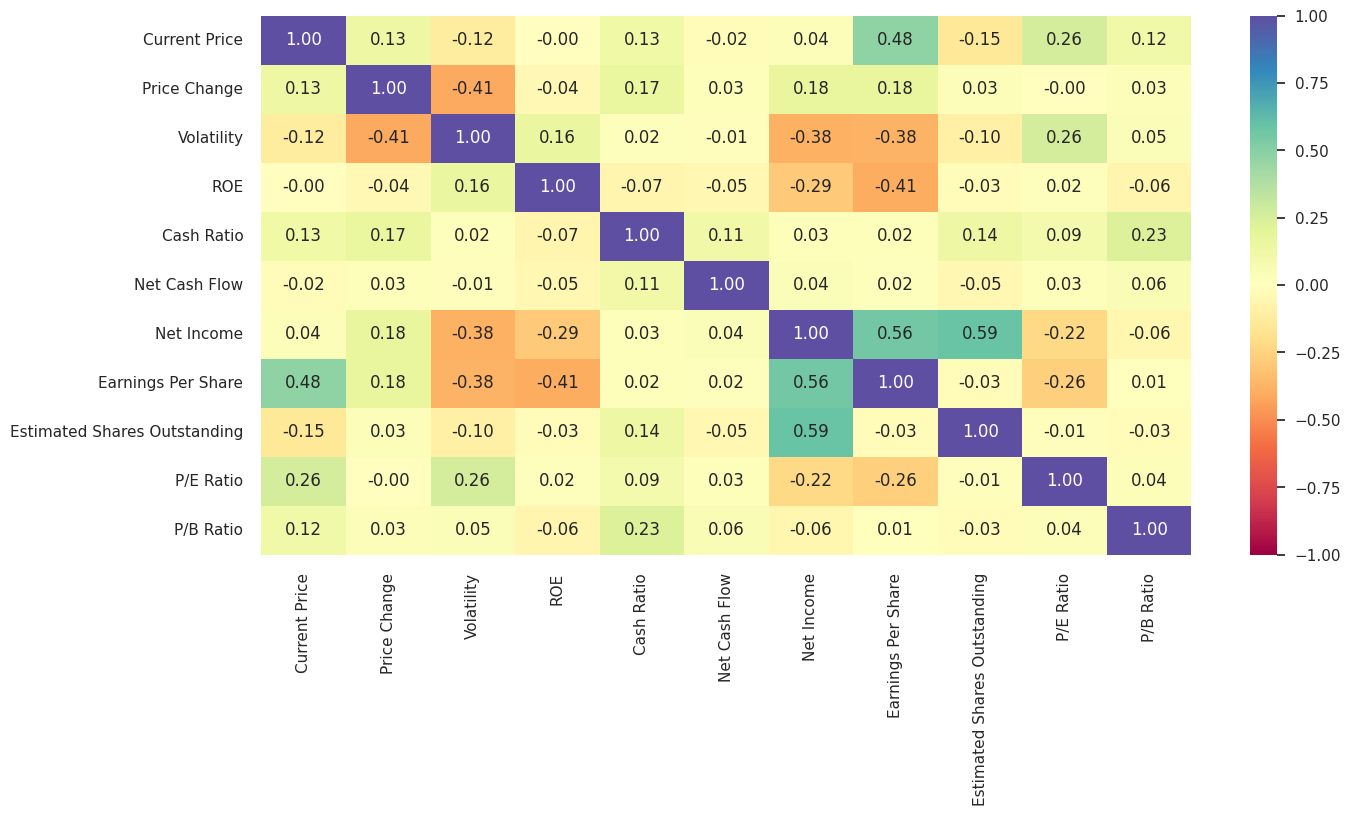

In [ ]:
# Create heatmap
plt.figure(figsize=(15, 7))
sns.heatmap(df[num_col].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

- Weak positive correlation between Net Income and Estimated Shares outstanding
- Weak positive correlation between Net Income Earnings per share
- Weak negative correlation between ROE and Earnings per Share
- Weak negative correlation between Volatility and Earnings per share

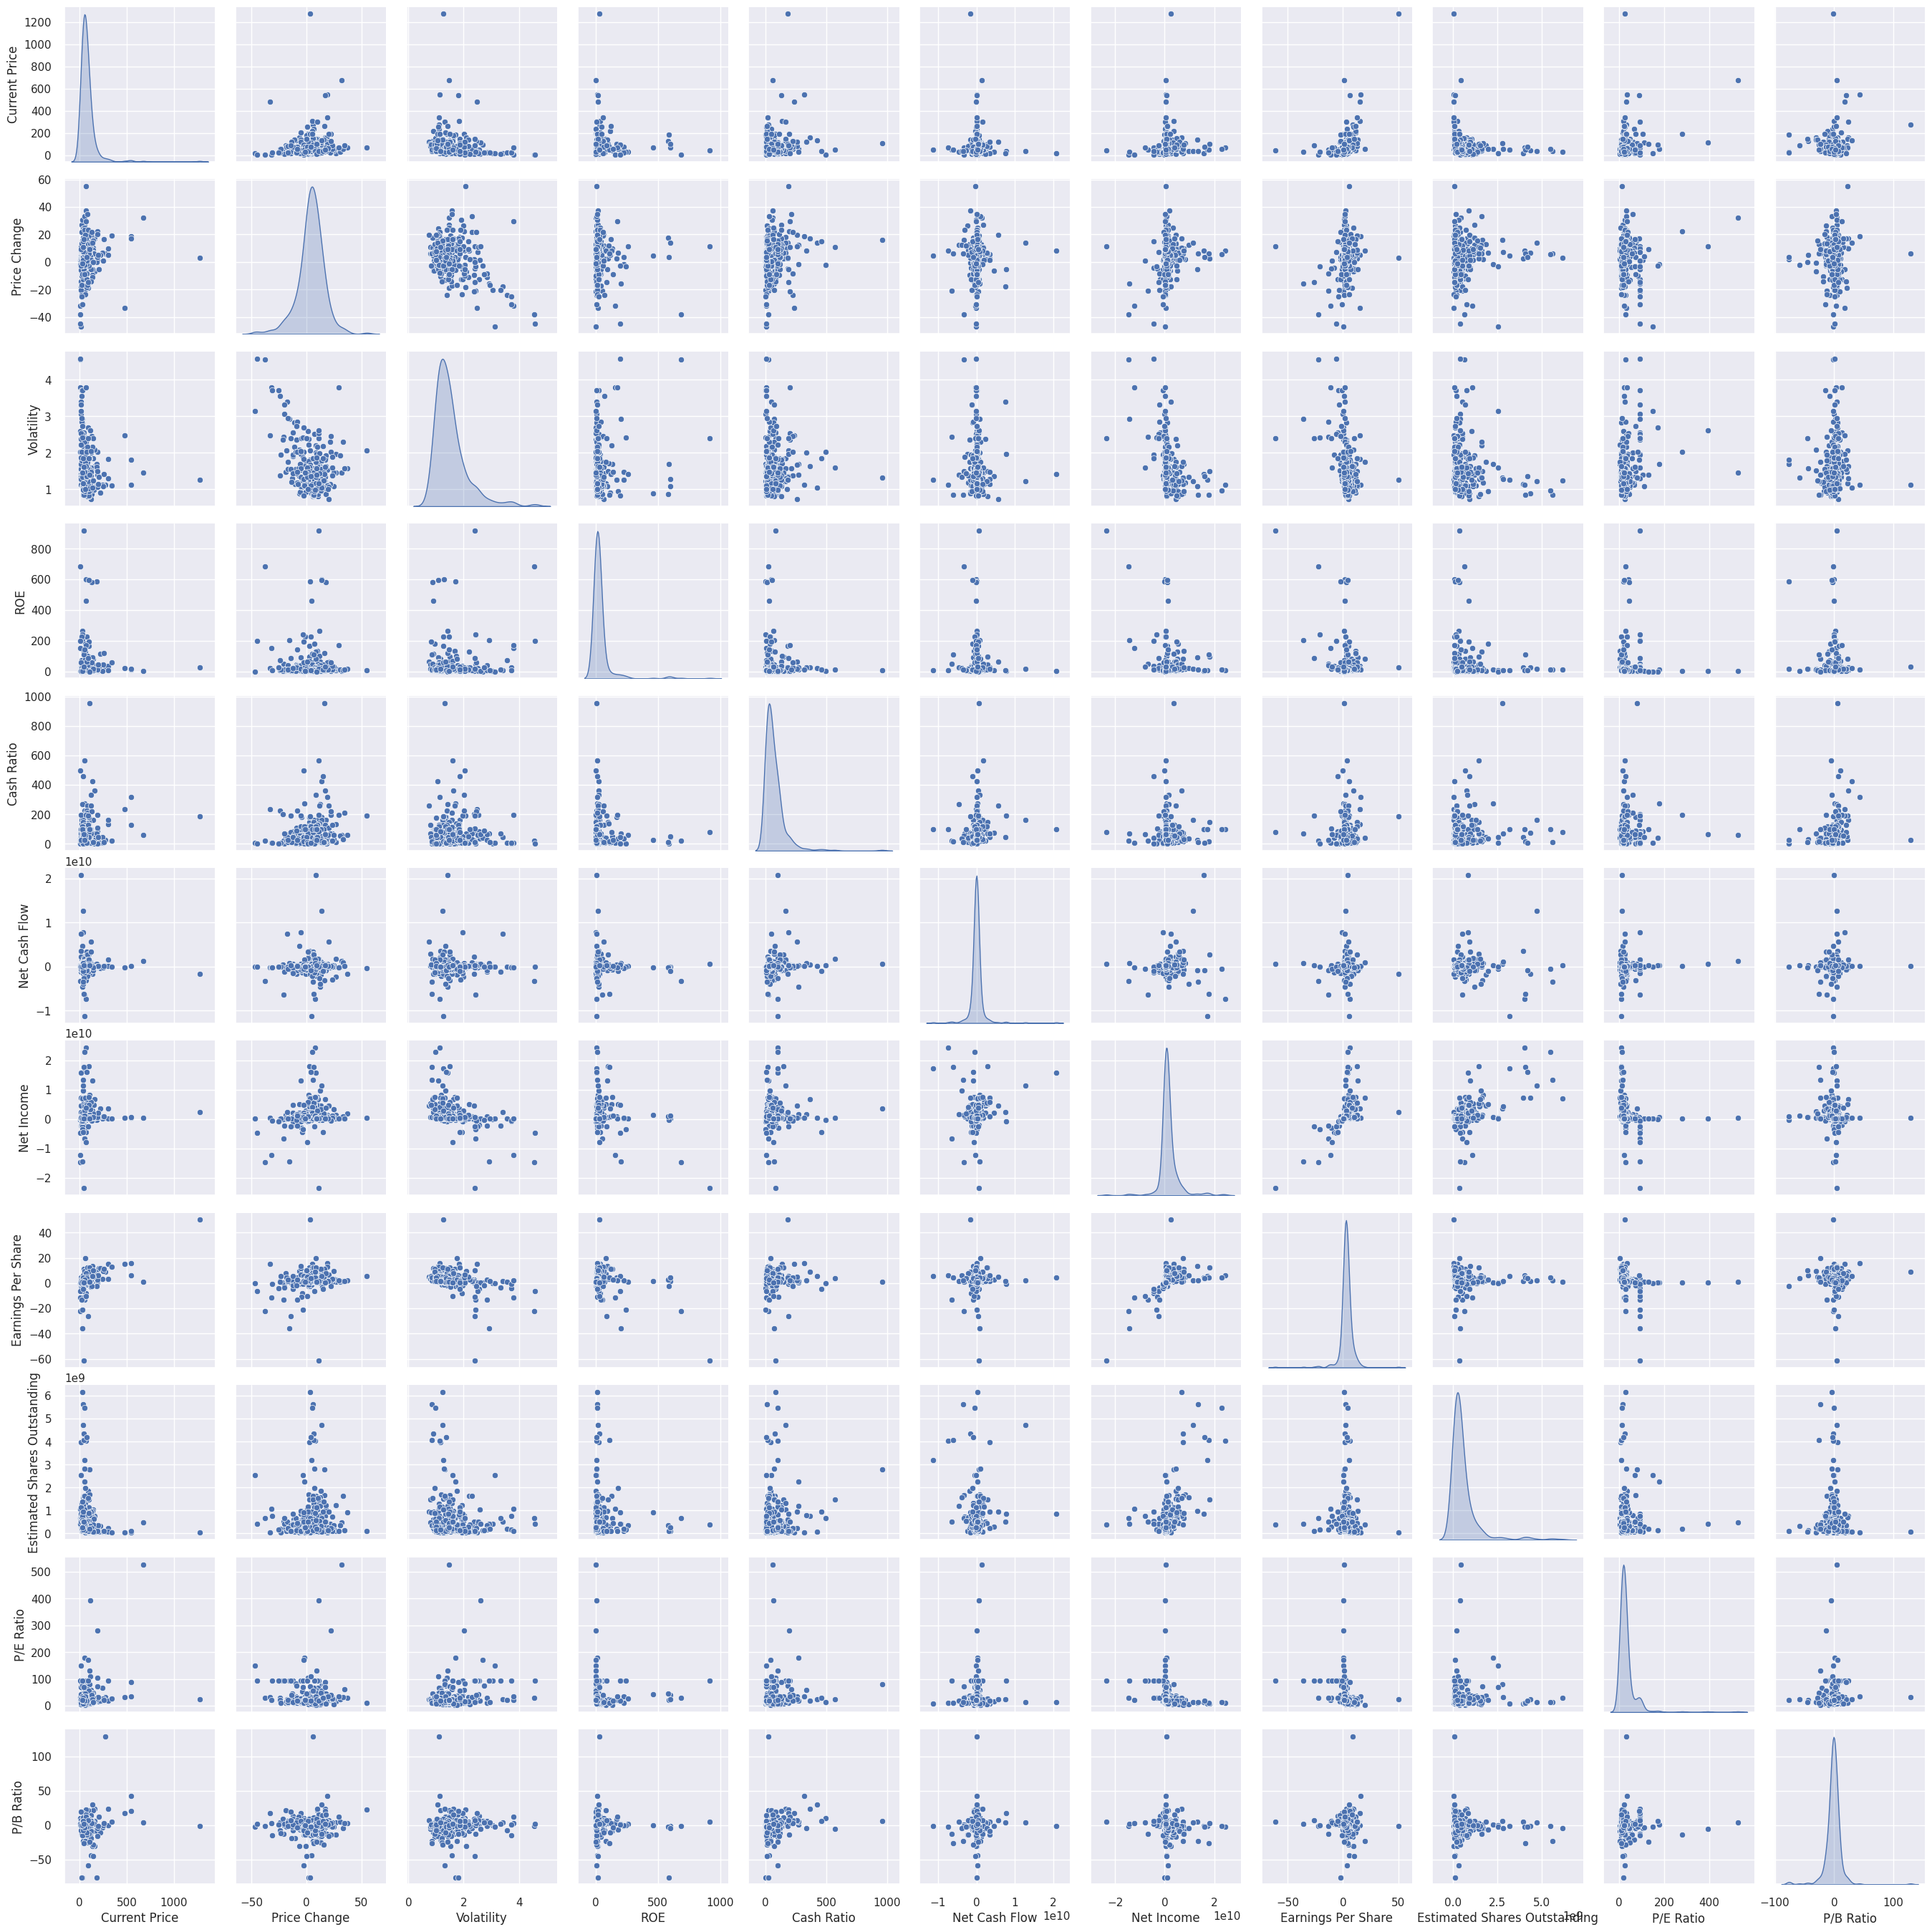

In [ ]:
sns.pairplot(data=df[num_col], diag_kind="kde")
plt.show()

- The data is not correlated

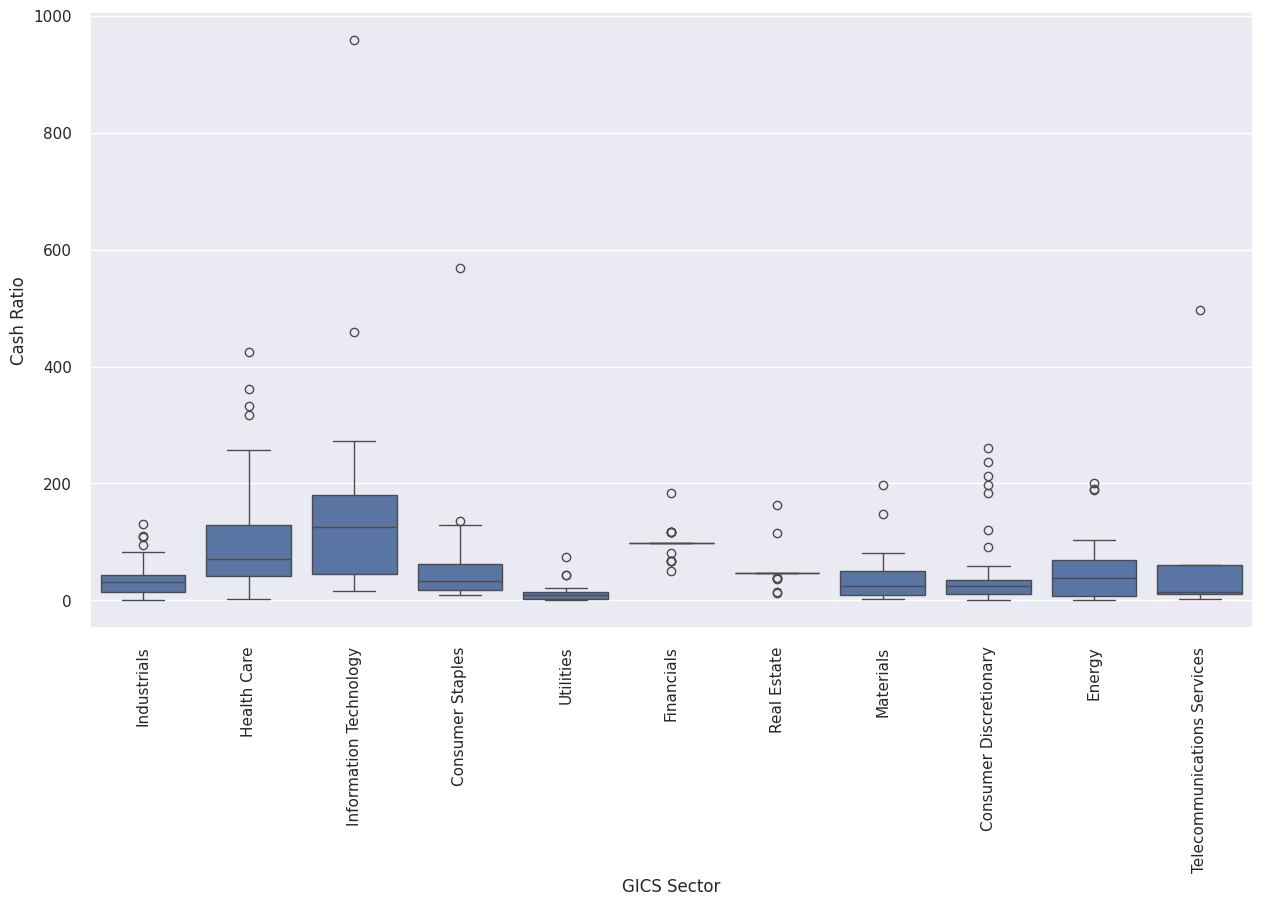

In [ ]:
#Cash ratio vs economic sectors in boxplot
plt.figure(figsize=(15, 8))
sns.boxplot(x="GICS Sector", y="Cash Ratio", data=df)
plt.xticks(rotation=90)
plt.show()

- Information Technology has the biggest cash ratio with a mean of about 120 and second is Health care with an average of about 80.
- The other sectors have a mean below 50.

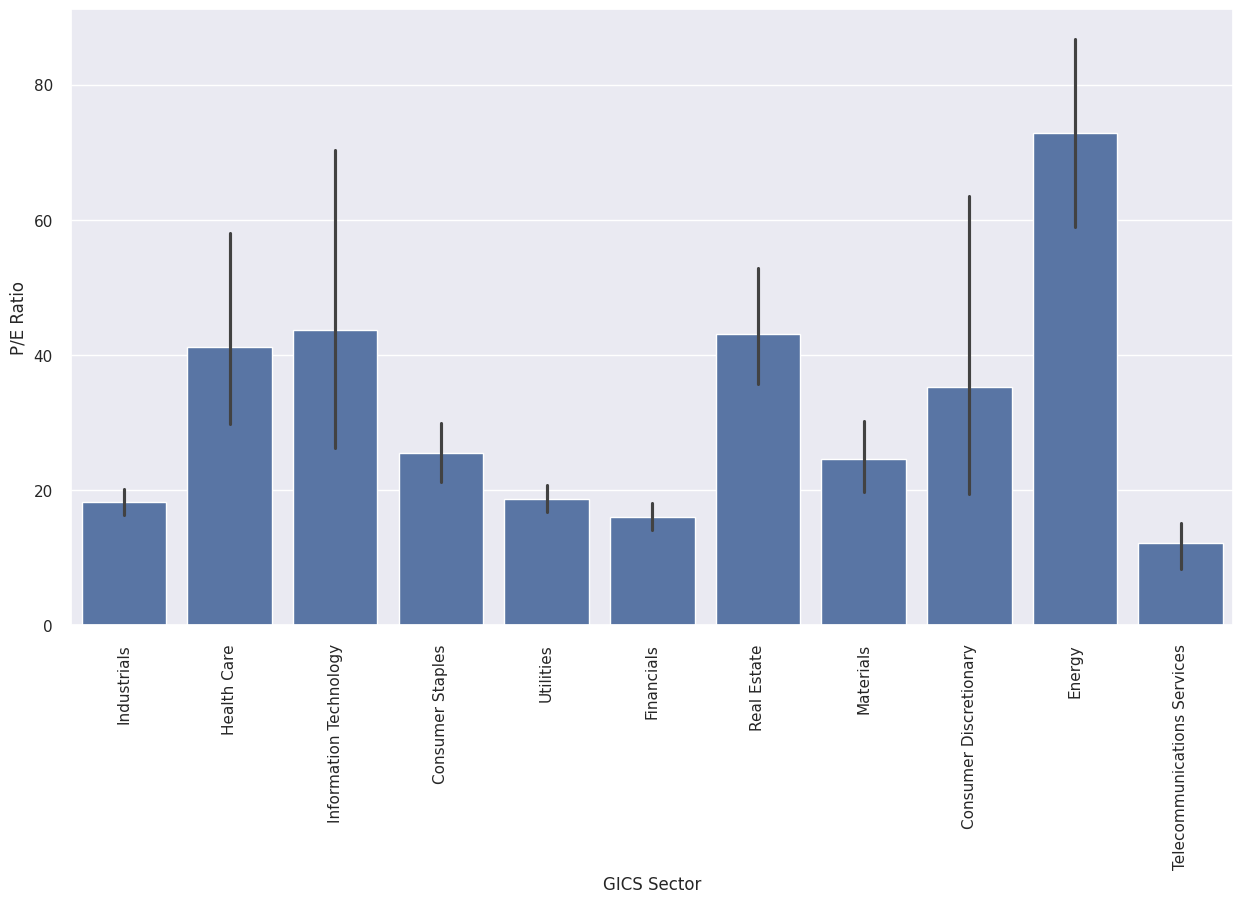

In [ ]:
# P/E versus the economic sectors in barplot
plt.figure(figsize=(15, 8))
sns.barplot(x="GICS Sector", y="P/E Ratio", data=df)
plt.xticks(rotation=90)
plt.show()


- The highest mean P/E ratio (70) is in the Energy industry.
-  The follows Information technology (45) , Real estate (45) and Health care (40)

## Data Preprocessing

- Duplicate value check
- Missing value treatment
- Outlier check
- Feature engineering (if needed)
- Any other preprocessing steps (if needed)

In [ ]:
# variables used for clustering
num_col

['Current Price',
 'Price Change',
 'Volatility',
 'ROE',
 'Cash Ratio',
 'Net Cash Flow',
 'Net Income',
 'Earnings Per Share',
 'Estimated Shares Outstanding',
 'P/E Ratio',
 'P/B Ratio']

In [ ]:
# scaling the dataset before clustering
scaler = StandardScaler()
subset = df[num_col].copy()
subset_scaled = scaler.fit_transform(subset)

In [ ]:
# creating a dataframe of the scaled columns
subset_scaled_df = pd.DataFrame(subset_scaled, columns=subset.columns)

###Treat outliers

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import seaborn as sns

# 1. Detect outliers using the IQR method
def remove_outliers_iqr(df, multiplier=1.5):
    """
    Remove outliers from a DataFrame using the IQR method.

    Parameters:
    - df: DataFrame containing the data
    - multiplier: IQR multiplier (default: 1.5)

    Returns:
    - DataFrame with outliers removed
    - DataFrame containing only the outliers
    """
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR

    # Create a mask for outlier detection
    outlier_mask = ((df < lower_bound) | (df > upper_bound)).any(axis=1)

    # Get non-outliers and outliers
    non_outliers = df[~outlier_mask]
    outliers = df[outlier_mask]

    print(f"Detected {outliers.shape[0]} outliers out of {df.shape[0]} observations ({outliers.shape[0]/df.shape[0]*100:.2f}%)")

    return non_outliers, outliers

# Apply outlier removal
data_cleaned, data_outliers = remove_outliers_iqr(subset_scaled_df)




Detected 182 outliers out of 340 observations (53.53%)


## K-means Clustering

Number of Clusters: 1 	Average Distortion: 2.5425069919221697
Number of Clusters: 2 	Average Distortion: 2.431736432420456
Number of Clusters: 3 	Average Distortion: 2.326590624339059
Number of Clusters: 4 	Average Distortion: 2.2828293407975306
Number of Clusters: 5 	Average Distortion: 2.2442837983528805
Number of Clusters: 6 	Average Distortion: 2.0917030591987187
Number of Clusters: 7 	Average Distortion: 2.0789412941963428
Number of Clusters: 8 	Average Distortion: 1.9790110296420294


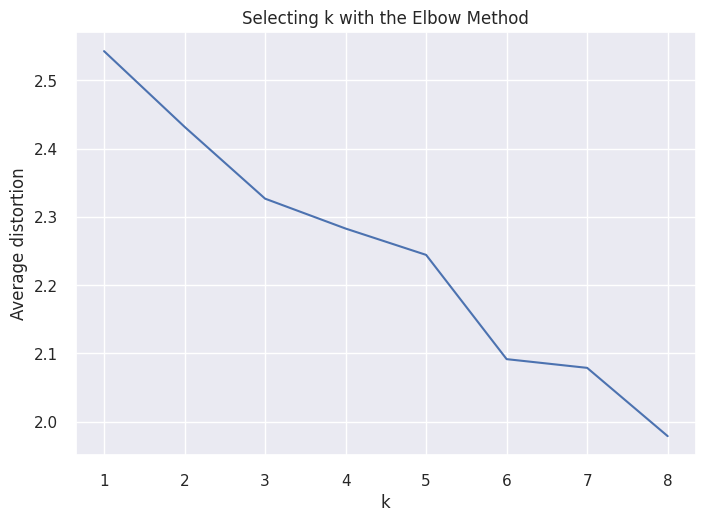

In [ ]:
clusters = range(1, 9)
meanDistortions = []

for k in clusters:
    model = KMeans(n_clusters=k)
    model.fit(subset_scaled_df)
    prediction = model.predict(subset_scaled_df)
    distortion = (
        sum(
            np.min(cdist(subset_scaled_df, model.cluster_centers_, "euclidean"), axis=1)
        )
        / subset_scaled_df.shape[0]
    )

    meanDistortions.append(distortion)

    print("Number of Clusters:", k, "\tAverage Distortion:", distortion)

plt.plot(clusters, meanDistortions, "bx-")
plt.xlabel("k")
plt.ylabel("Average distortion")
plt.title("Selecting k with the Elbow Method")
plt.show()

- Appropriate k value seems to be 4 or 6

###Let's check the silhouette scores


For n_clusters = 2, the silhouette score is 0.5030223852677932)
For n_clusters = 3, the silhouette score is 0.3770521145280117)
For n_clusters = 4, the silhouette score is 0.4214501561902374)
For n_clusters = 5, the silhouette score is 0.4261585110184136)
For n_clusters = 6, the silhouette score is 0.4232678320125665)
For n_clusters = 7, the silhouette score is 0.40970461257986346)
For n_clusters = 8, the silhouette score is 0.10228933132770664)
For n_clusters = 9, the silhouette score is 0.21154646529983176)


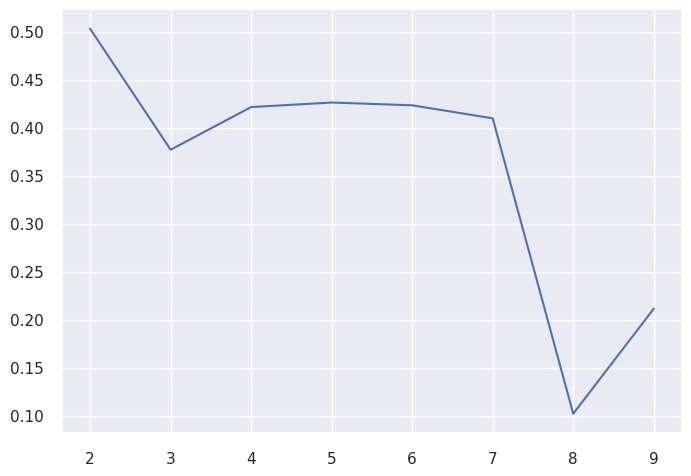

In [ ]:
sil_score = []
cluster_list = list(range(2, 10))
for n_clusters in cluster_list:
    clusterer = KMeans(n_clusters=n_clusters)
    preds = clusterer.fit_predict((subset_scaled_df))
    # centers = clusterer.cluster_centers_
    score = silhouette_score(subset_scaled_df, preds)
    sil_score.append(score)
    print("For n_clusters = {}, the silhouette score is {})".format(n_clusters, score))

plt.plot(cluster_list, sil_score)
plt.show()

- The silhoette score for 6 is just above the score for 4.
- Choose k value of 6.

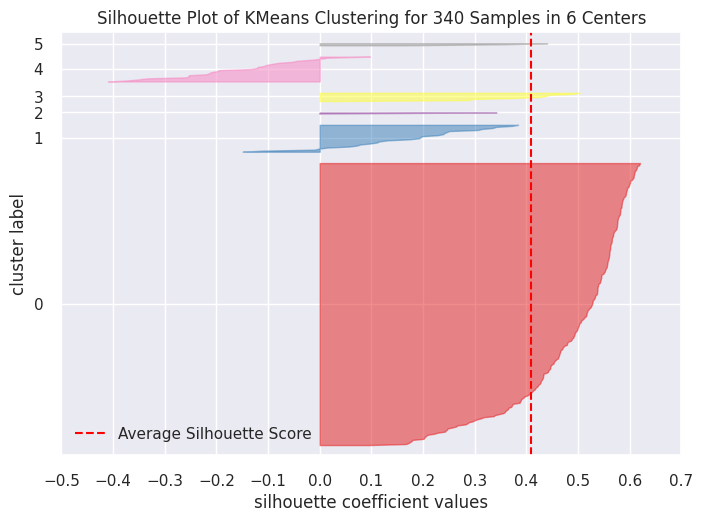

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 340 Samples in 6 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
# finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(6, random_state=1))
visualizer.fit(subset_scaled_df)
visualizer.show()

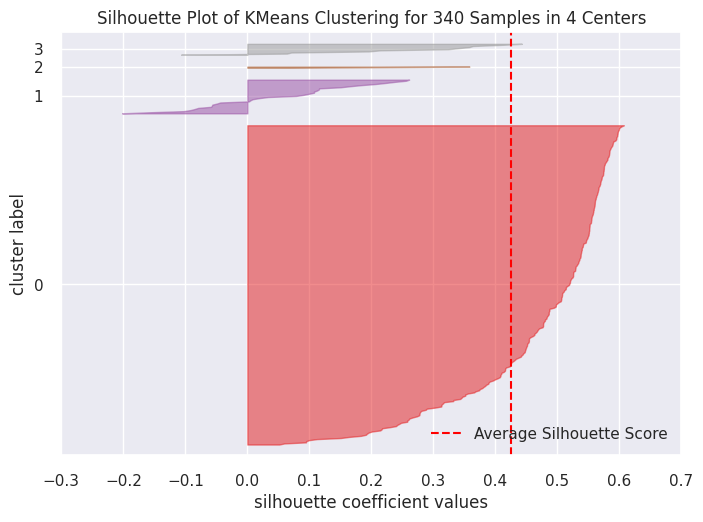

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 340 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
# finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(4, random_state=1))
visualizer.fit(subset_scaled_df)
visualizer.show()

In [ ]:
# let's take 6 as number of clusters
kmeans = KMeans(n_clusters=4, random_state=0)
kmeans.fit(subset_scaled_df)

KMeans(n_clusters=4, random_state=0)

In [ ]:
# adding kmeans cluster labels to the original and scaled dataframes

df["K_means_segments"] = kmeans.labels_
subset_scaled_df["K_means_segments"] = kmeans.labels_

###Cluster Profiling

In [ ]:
# Calculating the mean for only numerical features
cluster_profile = df.groupby("K_means_segments").agg({col: 'mean' for col in df.select_dtypes(include=np.number).columns})
# Displaying the cluster profile
cluster_profile["count_in_each_segments"] = df.groupby("K_means_segments")["Current Price"].count().values
cluster_profile.style.highlight_max(color="lightgreen", axis=0)

,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio,K_means_segments,count_in_each_segments
K_means_segments,,,,,,,,,,,,,
0,72.470050,5.059104,1.388717,34.710145,52.938406,-18021028.985507,1471488521.739130,3.628424,429936522.010181,23.808921,-3.355600,0.000000,276
1,35.165385,-16.390175,2.922214,110.961538,49.461538,-192318884.615385,-4041692307.692307,-9.849231,482610056.416923,78.934814,1.612922,1.000000,26
2,238.072932,13.508882,1.777479,25.600000,276.280000,752195440.000000,941997320.000000,5.889600,561429538.460800,90.217183,14.211965,2.000000,25
3,48.103077,6.053507,1.163964,27.538462,77.230769,773230769.230769,14114923076.923077,3.958462,3918734987.169230,16.098039,-4.253404,3.000000,13


In [ ]:
# let's display cluster profiles
cluster_profile.style.highlight_max(color="lightgreen", axis=0)

,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio,K_means_segments,count_in_each_segments
K_means_segments,,,,,,,,,,,,,
0,72.470050,5.059104,1.388717,34.710145,52.938406,-18021028.985507,1471488521.739130,3.628424,429936522.010181,23.808921,-3.355600,0.000000,276
1,35.165385,-16.390175,2.922214,110.961538,49.461538,-192318884.615385,-4041692307.692307,-9.849231,482610056.416923,78.934814,1.612922,1.000000,26
2,238.072932,13.508882,1.777479,25.600000,276.280000,752195440.000000,941997320.000000,5.889600,561429538.460800,90.217183,14.211965,2.000000,25
3,48.103077,6.053507,1.163964,27.538462,77.230769,773230769.230769,14114923076.923077,3.958462,3918734987.169230,16.098039,-4.253404,3.000000,13


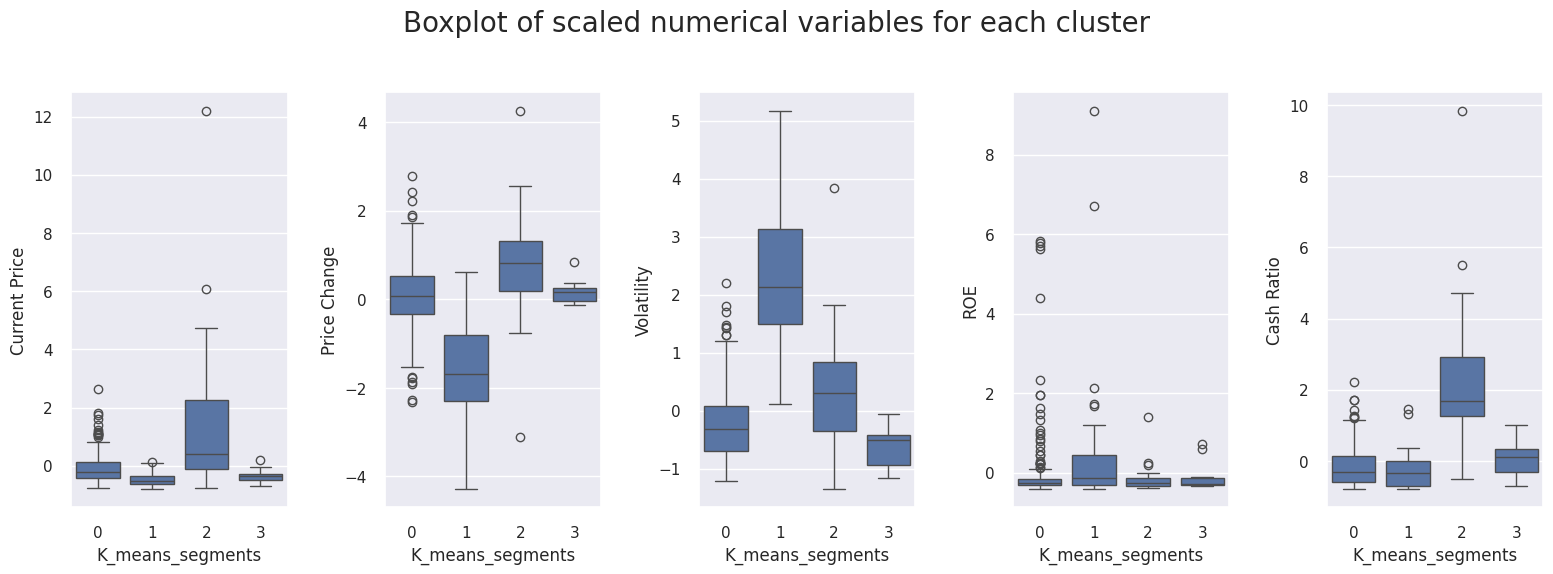

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(16, 6))
fig.suptitle("Boxplot of scaled numerical variables for each cluster", fontsize=20)
counter = 0
for ii in range(5):
    sns.boxplot(
        ax=axes[ii],
        y=subset_scaled_df[num_col[counter]],
        x=subset_scaled_df["K_means_segments"],
    )
    counter = counter + 1

fig.tight_layout(pad=2.0)

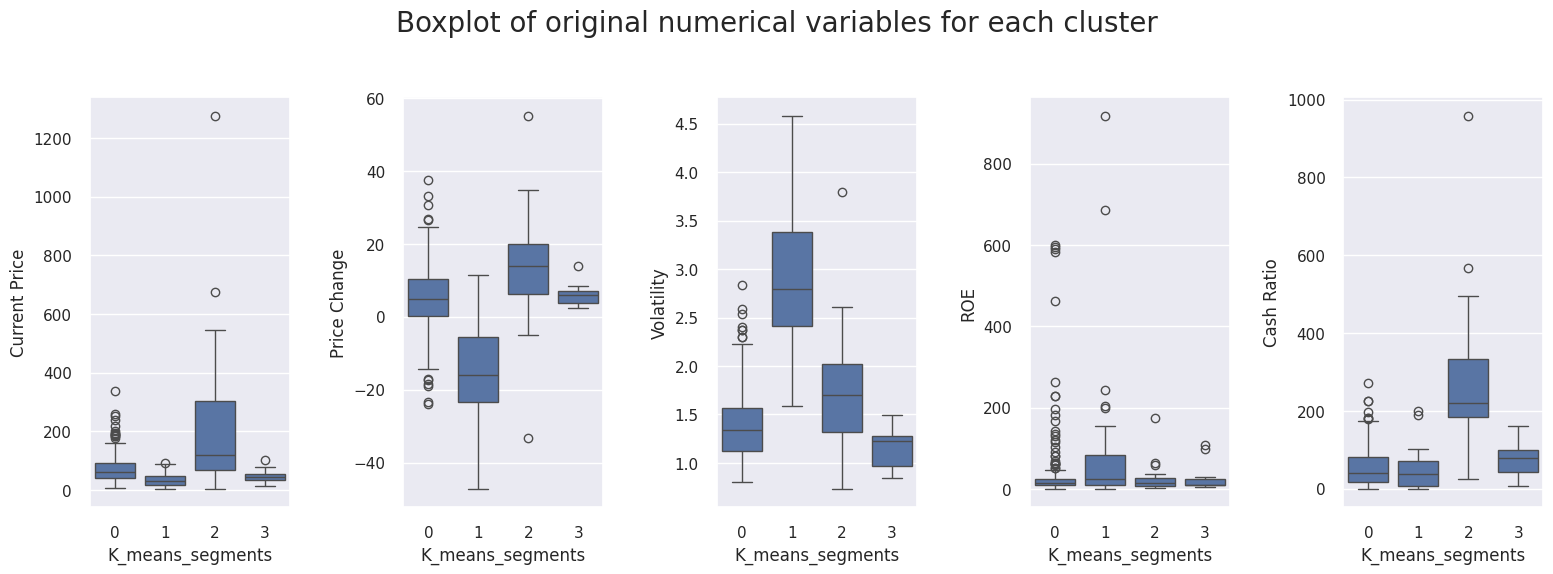

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(16, 6))
fig.suptitle("Boxplot of original numerical variables for each cluster", fontsize=20)
counter = 0
for ii in range(5):
    sns.boxplot(ax=axes[ii], y=df[num_col[counter]], x=df["K_means_segments"])
    counter = counter + 1

fig.tight_layout(pad=2.0)

###Insights

**Cluster 0** Stable Mid-Value Companies
- Average Current Price is about 80 dollors
- Average Price Change of 5 dollors
- Average Volatility of 1.4
- ROE close to zero
- Cash ration of about 5

**Cluster 1** Struggling Low-Value Stocks
- Average Current price of 5 dollors
- Average price change of -15
- Volatility of 2.7
- ROE of 5
- Average cash ratio of 5 dollors

**Cluster 2** Premium Growth Companies
- Average current price of 100 dollors with long positive tail
- Price change of 15
- Volatility of 1.7
- ROE of almost zero
- Average cash ratio of 220 with a long positive tail

**Cluster 3** Liquid Mid-Value Companies
- Average current price of 50 dollors
- Price change of 5 dollors
- Volatility of 1.3
- ROE of close to zero
- Cash ratio of 100


##Create cross tabulation table

###Cluster profile visualisation per sector

###Analyze distinctive sectors in each cluster

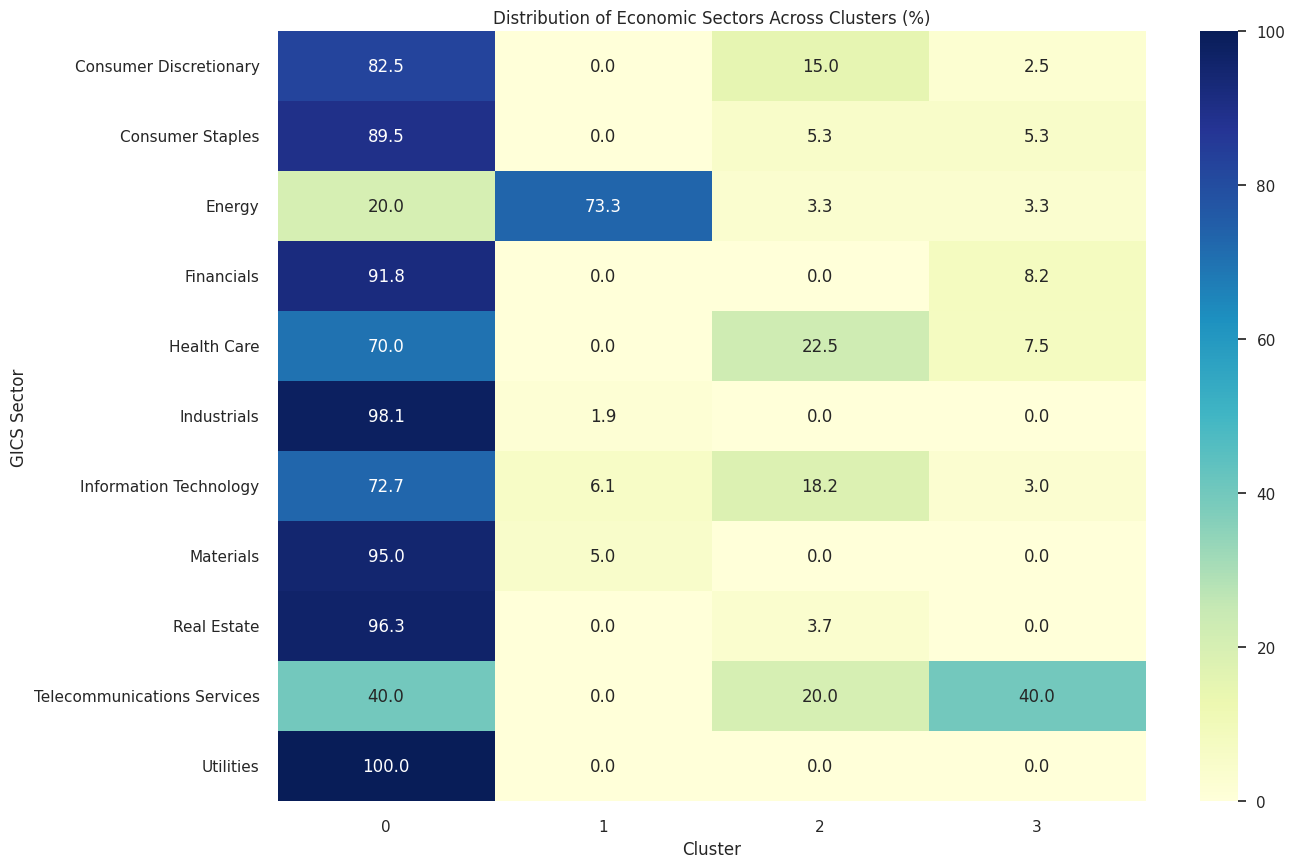

In [ ]:
# Add cluster assignments to your original dataframe
df['Cluster'] = kmeans.labels_

# Create a cross-tabulation
sector_cluster = pd.crosstab(df['GICS Sector'], df['Cluster'], normalize='index')

# View as percentages
sector_cluster_pct = sector_cluster * 100

# Visualize
plt.figure(figsize=(14, 10))
sns.heatmap(sector_cluster_pct, annot=True, cmap='YlGnBu', fmt='.1f')
plt.title('Distribution of Economic Sectors Across Clusters (%)')
plt.show()

In [ ]:
# Calculate percentage of each sector in each cluster
cluster_sector = pd.crosstab(df['Cluster'], df['GICS Sector'], normalize='index') * 100

# For each cluster, identify the top 3 most common sectors
for cluster in range(4):
    print(f"Cluster {cluster} most common sectors:")
    print(cluster_sector.loc[cluster].sort_values(ascending=False).head(3))
    print("\n")

Cluster 0 most common sectors:
GICS Sector
Industrials               18.840580
Financials                16.304348
Consumer Discretionary    11.956522
Name: 0, dtype: float64


Cluster 1 most common sectors:
GICS Sector
Energy                    84.615385
Information Technology     7.692308
Industrials                3.846154
Name: 1, dtype: float64


Cluster 2 most common sectors:
GICS Sector
Health Care               36.0
Information Technology    24.0
Consumer Discretionary    24.0
Name: 2, dtype: float64


Cluster 3 most common sectors:
GICS Sector
Financials                     30.769231
Health Care                    23.076923
Telecommunications Services    15.384615
Name: 3, dtype: float64




## Hierarchical Clustering

For n_clusters = 2, the silhouette score is 0.7419
For n_clusters = 3, the silhouette score is 0.7145
For n_clusters = 4, the silhouette score is 0.6514
For n_clusters = 5, the silhouette score is 0.6402
For n_clusters = 6, the silhouette score is 0.6272
For n_clusters = 7, the silhouette score is 0.6217
For n_clusters = 8, the silhouette score is 0.6142
For n_clusters = 9, the silhouette score is 0.5524
For n_clusters = 10, the silhouette score is 0.5320

Optimal number of clusters: 2 with silhouette score: 0.7419


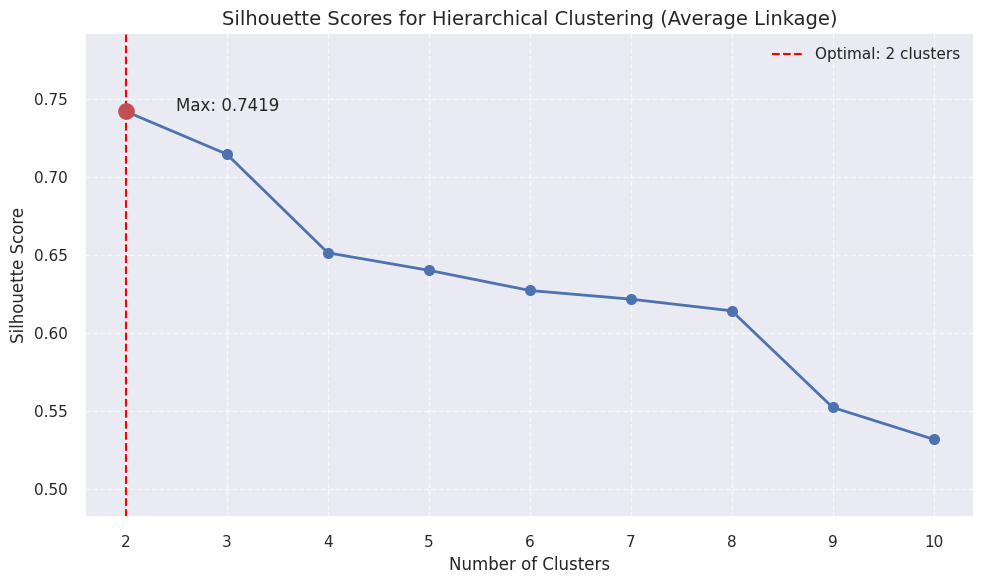


Silhouette scores for different numbers of clusters:
2 clusters: 0.7419
3 clusters: 0.7145
4 clusters: 0.6514
5 clusters: 0.6402
6 clusters: 0.6272
7 clusters: 0.6217
8 clusters: 0.6142
9 clusters: 0.5524
10 clusters: 0.5320


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import pdist

# Assuming subset_scaled is your preprocessed data
# First create the linkage matrix using average linkage (which had the best cophenet score)
Z = linkage(subset_scaled, metric='euclidean', method='average')

# Calculate silhouette scores for different numbers of clusters
max_clusters = 10
silhouette_scores = []
cluster_range = range(2, max_clusters + 1)

for n_clusters in cluster_range:
    # Get cluster labels by cutting the dendrogram
    cluster_labels = fcluster(Z, n_clusters, criterion='maxclust')

    # Calculate silhouette score
    silhouette_avg = silhouette_score(subset_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"For n_clusters = {n_clusters}, the silhouette score is {silhouette_avg:.4f}")

# Find the optimal number of clusters
optimal_n_clusters = cluster_range[np.argmax(silhouette_scores)]
max_silhouette = max(silhouette_scores)
print(f"\nOptimal number of clusters: {optimal_n_clusters} with silhouette score: {max_silhouette:.4f}")

# Create the line chart
plt.figure(figsize=(10, 6))
plt.plot(cluster_range, silhouette_scores, 'o-', linewidth=2, markersize=8)
plt.axvline(x=optimal_n_clusters, color='red', linestyle='--', label=f'Optimal: {optimal_n_clusters} clusters')

# Highlight the maximum silhouette score
plt.plot(optimal_n_clusters, max_silhouette, 'ro', markersize=12)
plt.annotate(f'Max: {max_silhouette:.4f}',
             xy=(optimal_n_clusters, max_silhouette),
             xytext=(optimal_n_clusters+0.5, max_silhouette),
             fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)
plt.xlabel('Number of Clusters', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Scores for Hierarchical Clustering (Average Linkage)', fontsize=14)
plt.xticks(cluster_range)
plt.ylim([min(silhouette_scores) - 0.05, max(silhouette_scores) + 0.05])
plt.legend()
plt.tight_layout()
plt.show()

# For comparison, print all silhouette scores in a table format
print("\nSilhouette scores for different numbers of clusters:")
for i, n_clusters in enumerate(cluster_range):
    print(f"{n_clusters} clusters: {silhouette_scores[i]:.4f}")

In [ ]:
from sklearn.cluster import AgglomerativeClustering

In [ ]:
model = AgglomerativeClustering(n_clusters=2,  linkage='average')

In [ ]:
model.fit(subset_scaled_df)

AgglomerativeClustering(linkage='average')

In [ ]:
subset_scaled_df['labels'] = model.labels_
subset_scaled_df.head(10)
#subset_scaled_df.groupby(["labels"]).count()

,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio,K_means_segments,labels
0,-0.393341,0.493950,0.272749,0.989601,-0.210698,-0.339355,1.554415,1.309399,0.107863,-0.652487,-0.506653,0,0
1,-0.220837,0.355439,1.137045,0.937737,0.077269,-0.002335,0.927628,0.056755,1.250274,-0.311769,-0.504205,0,0
2,-0.367195,0.602479,-0.427007,-0.192905,-0.033488,0.454058,0.744371,0.024831,1.098021,-0.391502,0.094941,0,0
3,0.133567,0.825696,-0.284802,-0.317379,1.218059,-0.152497,-0.219816,-0.230563,-0.091622,0.947148,0.424333,0,0
4,-0.260874,-0.492636,0.296470,-0.265515,2.237018,0.133564,-0.202703,-0.374982,1.978399,3.293307,0.199196,2,0
5,-0.451251,-1.342556,-0.016049,-0.307006,-0.232849,-0.125823,0.090133,0.032432,0.048977,-0.459427,0.660752,0,0
6,1.998837,0.176091,-0.692132,-0.099549,-0.498664,0.018187,-0.228206,0.932390,-0.603923,-0.035502,9.377562,2,0
7,-0.384353,-0.158797,-0.679931,-0.317379,-0.620496,0.119096,-0.218177,-0.026856,-0.393572,-0.360984,0.071614,0,0
8,-0.230744,-0.142338,-0.774192,-0.296633,-0.675874,-0.021424,0.141806,0.053714,-0.183672,-0.319668,-0.093530,0,0
9,-0.214096,-0.087667,-0.808359,-0.265515,0.320933,-0.187053,0.263986,0.471769,-0.173153,-0.506408,-0.011879,0,0


In [ ]:
subset_scaledClust =subset_scaled_df.groupby(['labels'])

In [ ]:
subset_scaledClust.mean()

,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio,K_means_segments
labels,,,,,,,,,,,,
0,-0.035975,0.000218,0.001286,0.000324,-0.003724,0.002621,-0.000792,-0.021217,0.001837,0.000477,-0.000141,0.333333
1,12.195670,-0.074042,-0.435986,-0.109922,1.262362,-0.888563,0.268653,7.192572,-0.622886,-0.161672,0.047742,2.000000


In [ ]:
from scipy.cluster.hierarchy import cophenet, dendrogram, linkage

In [ ]:
from scipy.spatial.distance import pdist  #Pairwise distribution between data points

In [ ]:
# cophenet index is a measure of the correlation between the distance of points in feature space and distance on dendrogram
# closer it is to 1, the better is the clustering

Z = linkage(subset_scaled, metric='euclidean', method='average')
c, coph_dists = cophenet(Z , pdist(subset_scaled))

c

np.float64(0.9422540609560814)

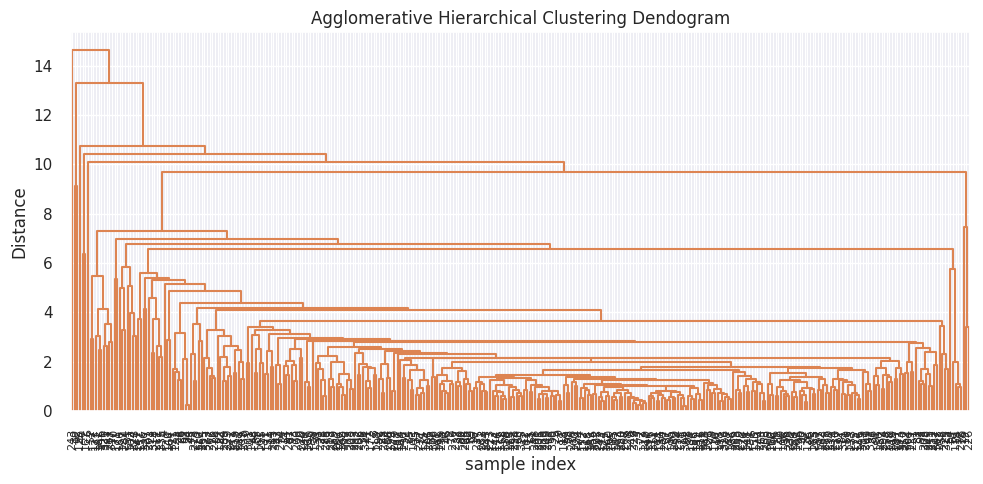

In [ ]:
plt.figure(figsize=(10, 5))
plt.title('Agglomerative Hierarchical Clustering Dendogram')
plt.xlabel('sample index')
plt.ylabel('Distance')
dendrogram(Z, leaf_rotation=90.,color_threshold = 40, leaf_font_size=8. )
plt.tight_layout()

In [ ]:
# cophenet index is a measure of the correlation between the distance of points in feature space and distance on dendrogram
# closer it is to 1, the better is the clustering

Z = linkage(subset_scaled, metric='euclidean', method='complete')
c, coph_dists = cophenet(Z , pdist(subset_scaled))

c

np.float64(0.7873280186580672)

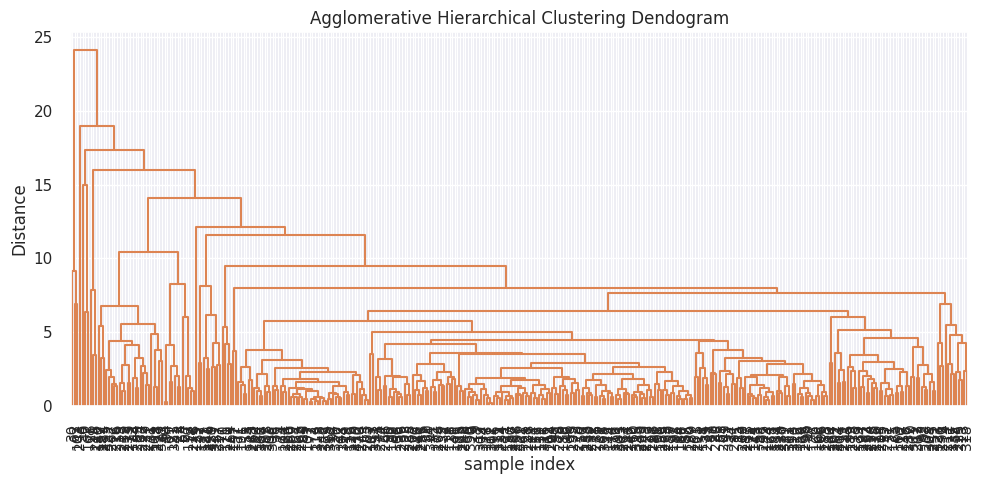

In [ ]:
plt.figure(figsize=(10, 5))
plt.title('Agglomerative Hierarchical Clustering Dendogram')
plt.xlabel('sample index')
plt.ylabel('Distance')
dendrogram(Z, leaf_rotation=90.,color_threshold=90,  leaf_font_size=10. )
plt.tight_layout()

In [ ]:
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, cophenet, fcluster

# cophenet index is a measure of the correlation between the distance of points in feature space and distance on dendrogram
# closer it is to 1, the better is the clustering
Z = linkage(subset_scaled, metric='euclidean', method='ward')
c, coph_dists = cophenet(Z , pdist(subset_scaled))

c

np.float64(0.7101180299865353)

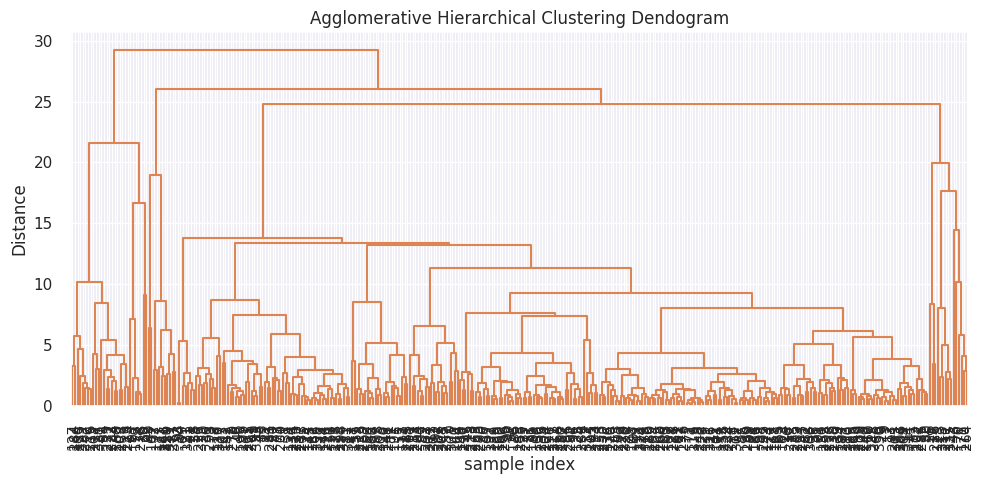

In [ ]:
plt.figure(figsize=(10, 5))
plt.title('Agglomerative Hierarchical Clustering Dendogram')
plt.xlabel('sample index')
plt.ylabel('Distance')
dendrogram(Z, leaf_rotation=90.,color_threshold=600,  leaf_font_size=10. )
plt.tight_layout()


Percentage distribution of observations in K-means clusters (after outlier removal):
Cluster 0: 19.62%
Cluster 1: 22.78%
Cluster 2: 18.99%
Cluster 3: 38.61%

Percentage distribution of observations in Hierarchical clusters (after outlier removal):
Cluster 1: 96.20%
Cluster 2: 2.53%
Cluster 3: 0.63%
Cluster 4: 0.63%

Cross-tabulation of cluster assignments (after outlier removal):
Hierarchical   1  2  3  4
K-means                  
0             30  1  0  0
1             31  3  1  1
2             30  0  0  0
3             61  0  0  0


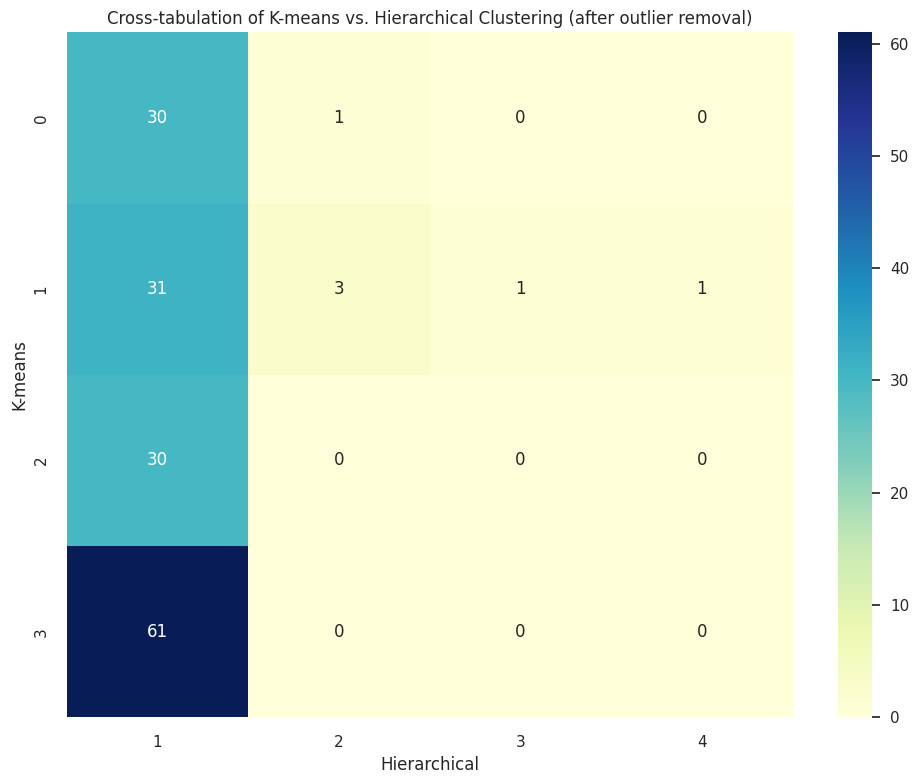


Silhouette scores after outlier removal:
K-means: 0.1622
Hierarchical: 0.2244


In [ ]:
#  Re-run K-means clustering on cleaned data
n_clusters_kmeans = 4  # You can adjust this
kmeans = KMeans(n_clusters=n_clusters_kmeans, random_state=42, n_init=10)
kmeans_labels_cleaned = kmeans.fit_predict(data_cleaned)

# Re-run hierarchical clustering on cleaned data
Z_cleaned = linkage(data_cleaned, metric='euclidean', method='average')
h_labels_cleaned = fcluster(Z_cleaned, n_clusters_kmeans, criterion='maxclust')

# Analyze the new cluster distributions
kmeans_distribution = pd.Series(kmeans_labels_cleaned).value_counts().sort_index() / len(kmeans_labels_cleaned) * 100
hierarchical_distribution = pd.Series(h_labels_cleaned).value_counts().sort_index() / len(h_labels_cleaned) * 100

print("\nPercentage distribution of observations in K-means clusters (after outlier removal):")
for cluster, percentage in kmeans_distribution.items():
    print(f"Cluster {cluster}: {percentage:.2f}%")

print("\nPercentage distribution of observations in Hierarchical clusters (after outlier removal):")
for cluster, percentage in hierarchical_distribution.items():
    print(f"Cluster {cluster}: {percentage:.2f}%")

# Create cross-tabulation of new clusters
comparison_df = pd.DataFrame({
    'KMeans_Cluster': kmeans_labels_cleaned,
    'Hierarchical_Cluster': h_labels_cleaned
})

cross_tab = pd.crosstab(
    comparison_df['KMeans_Cluster'],
    comparison_df['Hierarchical_Cluster'],
    rownames=['K-means'],
    colnames=['Hierarchical']
)

print("\nCross-tabulation of cluster assignments (after outlier removal):")
print(cross_tab)

# Visualize the cross-tabulation as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cross_tab, annot=True, cmap="YlGnBu", fmt="d", cbar=True)
plt.title('Cross-tabulation of K-means vs. Hierarchical Clustering (after outlier removal)')
plt.tight_layout()
plt.show()

# Calculate silhouette scores for both methods on cleaned data
kmeans_silhouette = silhouette_score(data_cleaned, kmeans_labels_cleaned)
hierarchical_silhouette = silhouette_score(data_cleaned, h_labels_cleaned)

print(f"\nSilhouette scores after outlier removal:")
print(f"K-means: {kmeans_silhouette:.4f}")
print(f"Hierarchical: {hierarchical_silhouette:.4f}")

## K-means vs Hierarchical Clustering


- The K means clustering technique took less time for execution, but the hierarchical clustering was also rapid.
- The K means method gave more distinct economical interpretable clusters.
- How many observations are there in the similar clusters of both algorithms: Very few, since hierarchical clustering is placing nearly all observations in a single cluster.
- How many clusters are obtained as the appropriate number of clusters from both algorithms? For K-means, 4 clusters now appears reasonable with a good balance; for hierarchical clustering, the method isn't creating meaningful clusters regardless of the number.

## Actionable Insights and Recommendations


Insights:

- K-means is the superior method for the dataset: After outlier removal, K-means produced well-balanced clusters (19.6%, 22.8%, 19.0%, and 38.6% distribution), while hierarchical clustering continued to place 96.2% of observations in a single cluster.
- Outlier removal was critical: This significantly improved the clustering quality, particularly for K-means, transforming from one dominant cluster (80%+) to a more balanced distribution.
- The data likely lacks hierarchical structure: Despite the high cophenet score (0.942), hierarchical clustering failed to create meaningful groups, suggesting the data doesn't naturally organize in a hierarchical manner.
- Four clusters appear optimal for K-means: This provides a good balance between detail and interpretability based on the cleaned dataset.

Recommendations:

Investment Strategy Applications:

Target investment approaches specific to each cluster:

- For the "Premium Growth Companies" cluster: Focus on long-term growth potential.
- For the "Stable Mid-Value Companies" cluster: Consider for balanced portfolio components.
- For the "Liquid Mid-Value Companies" cluster: Evaluate for cash flow and liquidity needs.
- For the "Struggling Low-Value Stocks" cluster: Monitor for turnaround potential or avoid.

Practical Application:

- Create a scoring system that helps classify new companies into one of these established clusters.


=== Clustering Metrics ===
Original Data:
  Silhouette (Euclidean): 0.7460
  Silhouette (Manhattan): 0.7457
  ARI (Euclidean): 1.0000
  ARI (Manhattan): 1.0000

Clipped Data:
  Silhouette (Euclidean): 0.7925
  Silhouette (Manhattan): 0.7925
  ARI (Euclidean): 1.0000
  ARI (Manhattan): 1.0000

=== Classification Metrics ===
With Outliers:
  Accuracy (Euclidean): 0.8901
  Accuracy (Manhattan): 0.8901

With Clipped Outliers:
  Accuracy (Euclidean): 0.8901
  Accuracy (Manhattan): 0.8901

=== Summary of Improvements ===
Manhattan vs Euclidean (Original): -0.04% improvement in clustering
Clipping vs Original (Euclidean): 6.23% improvement in clustering
Manhattan vs Euclidean (Classification): 0.00% improvement in accuracy
Clipping vs Original (Classification): 0.00% improvement in accuracy


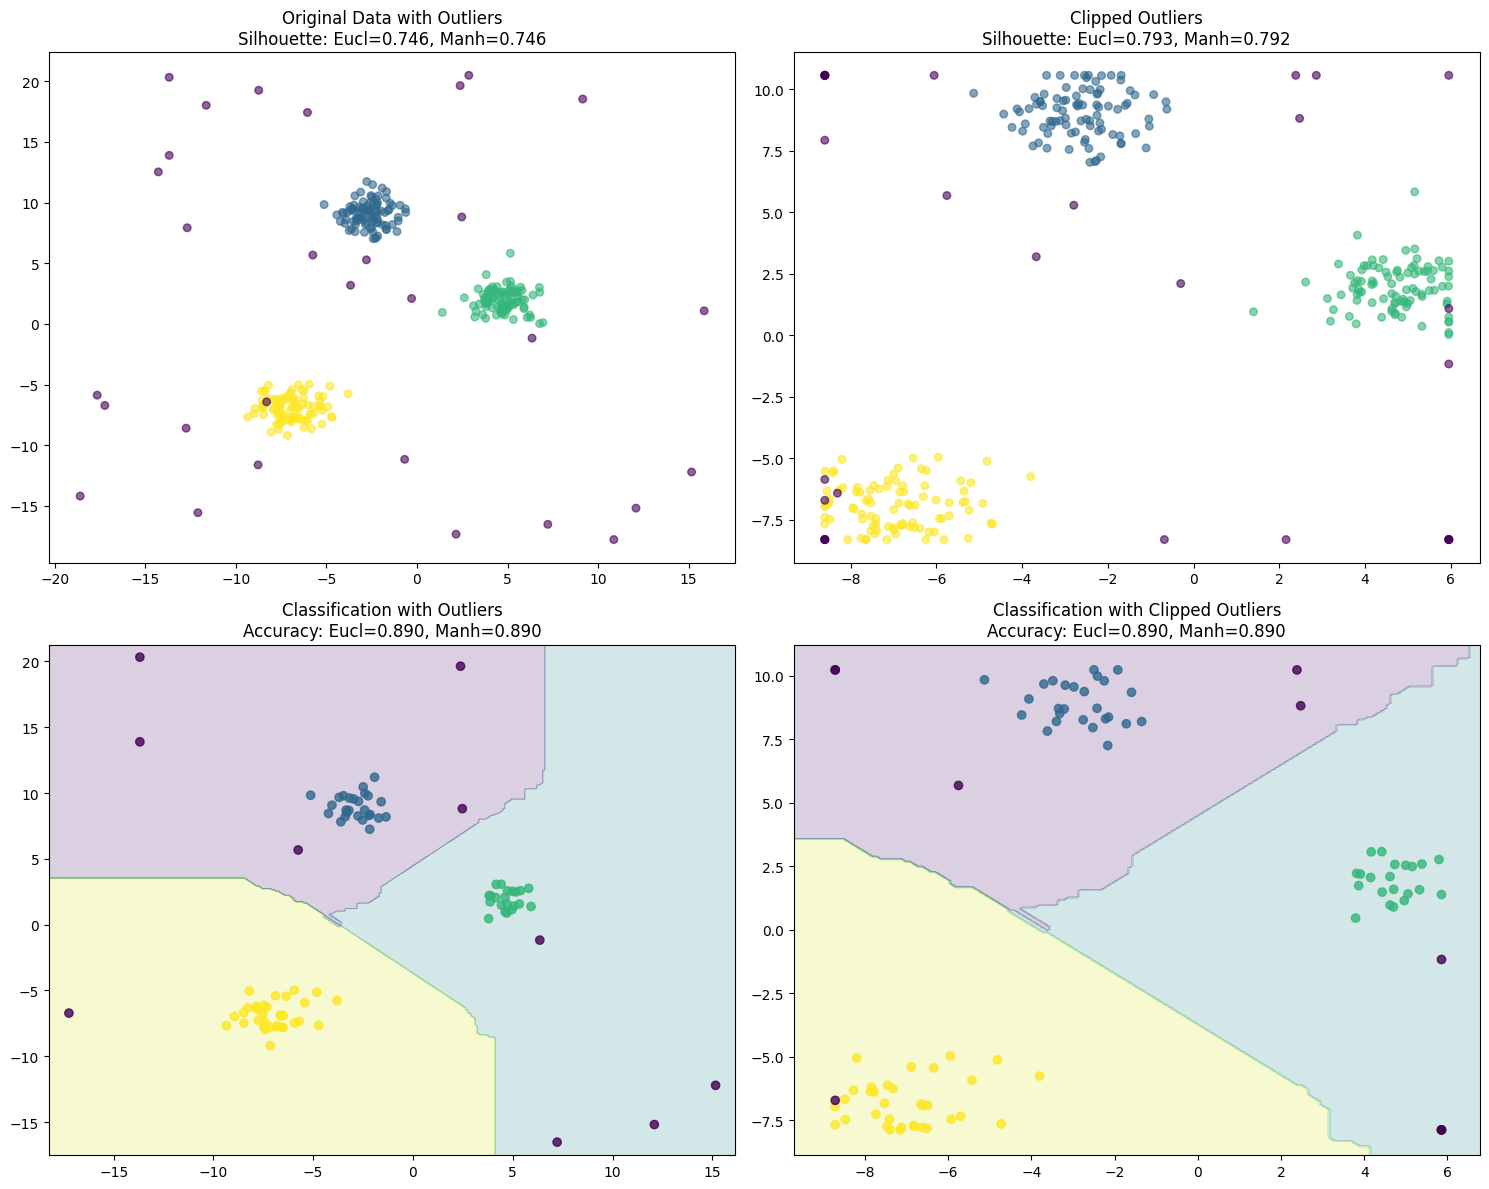

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.neighbors import KNeighborsClassifier
from scipy.spatial.distance import cdist

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic dataset with outliers
def generate_data_with_outliers(n_samples=300, n_outliers=30, n_clusters=3):
    # Generate the core data
    X, y = make_blobs(n_samples=n_samples-n_outliers, centers=n_clusters,
                      cluster_std=1.0, random_state=42)

    # Generate outliers
    outliers_x = np.random.uniform(low=np.min(X[:, 0])-10, high=np.max(X[:, 0])+10, size=n_outliers)
    outliers_y = np.random.uniform(low=np.min(X[:, 1])-10, high=np.max(X[:, 1])+10, size=n_outliers)
    outliers = np.column_stack((outliers_x, outliers_y))
    outlier_labels = np.full(n_outliers, -1)  # Label outliers as -1

    # Combine core data with outliers
    X_with_outliers = np.vstack((X, outliers))
    y_with_outliers = np.concatenate((y, outlier_labels))

    return X_with_outliers, y_with_outliers

# Clip outliers based on percentile thresholds
def clip_outliers(X, lower_percentile=5, upper_percentile=95):
    X_clipped = X.copy()
    for col in range(X.shape[1]):
        lower_bound = np.percentile(X[:, col], lower_percentile)
        upper_bound = np.percentile(X[:, col], upper_percentile)
        X_clipped[:, col] = np.clip(X_clipped[:, col], lower_bound, upper_bound)
    return X_clipped

# Evaluate clustering with different distance metrics and outlier handling
def evaluate_clustering(X, y_true, title, ax):
    # K-means with Euclidean distance (standard)
    kmeans_euclidean = KMeans(n_clusters=3, random_state=42)
    y_pred_euclidean = kmeans_euclidean.fit_predict(X)
    silhouette_euclidean = silhouette_score(X, y_pred_euclidean)

    # Manually implement k-means with Manhattan distance
    def kmeans_manhattan(X, n_clusters=3, max_iters=100):
        # Initialize centroids randomly
        indices = np.random.choice(X.shape[0], n_clusters, replace=False)
        centroids = X[indices]

        for _ in range(max_iters):
            # Assign points to nearest centroid using Manhattan distance
            distances = cdist(X, centroids, metric='cityblock')
            labels = np.argmin(distances, axis=1)

            # Update centroids
            new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(n_clusters)])

            # Check for convergence
            if np.all(centroids == new_centroids):
                break

            centroids = new_centroids

        return labels, centroids

    y_pred_manhattan, _ = kmeans_manhattan(X)
    silhouette_manhattan = silhouette_score(X, y_pred_manhattan)

    # Plot the results
    ax.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', alpha=0.6, s=30)
    ax.set_title(f"{title}\nSilhouette: Eucl={silhouette_euclidean:.3f}, Manh={silhouette_manhattan:.3f}")

    # Return metrics for comparison
    metrics = {
        'silhouette_euclidean': silhouette_euclidean,
        'silhouette_manhattan': silhouette_manhattan,
        'ari_euclidean': adjusted_rand_score(y_true[y_true != -1], y_pred_euclidean[y_true != -1]),
        'ari_manhattan': adjusted_rand_score(y_true[y_true != -1], y_pred_manhattan[y_true != -1])
    }
    return metrics

# Classification with Manhattan vs Euclidean with outliers
def evaluate_classification(X_train, y_train, X_test, y_test, title, ax):
    # KNN with Euclidean distance
    knn_euclidean = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
    knn_euclidean.fit(X_train, y_train)
    acc_euclidean = knn_euclidean.score(X_test, y_test)

    # KNN with Manhattan distance
    knn_manhattan = KNeighborsClassifier(n_neighbors=5, metric='manhattan')
    knn_manhattan.fit(X_train, y_train)
    acc_manhattan = knn_manhattan.score(X_test, y_test)

    # Plot decision boundaries
    x_min, x_max = X_test[:, 0].min() - 1, X_test[:, 0].max() + 1
    y_min, y_max = X_test[:, 1].min() - 1, X_test[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))

    Z = knn_manhattan.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.2, cmap='viridis')
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='viridis', alpha=0.8)
    ax.set_title(f"{title}\nAccuracy: Eucl={acc_euclidean:.3f}, Manh={acc_manhattan:.3f}")

    # Return metrics for comparison
    metrics = {
        'accuracy_euclidean': acc_euclidean,
        'accuracy_manhattan': acc_manhattan
    }
    return metrics

# Main experiment
def run_comparison():
    # Generate data
    X, y = generate_data_with_outliers(n_samples=300, n_outliers=30)

    # Filter out points labeled as outliers for true class evaluation
    mask = y != -1
    X_no_outliers, y_no_outliers = X[mask], y[mask]

    # Split into training and test sets
    indices = np.random.permutation(len(X_no_outliers))
    train_size = int(0.7 * len(X_no_outliers))
    train_idx, test_idx = indices[:train_size], indices[train_size:]

    X_train, y_train = X_no_outliers[train_idx], y_no_outliers[train_idx]
    X_test, y_test = X_no_outliers[test_idx], y_no_outliers[test_idx]

    # Add some outliers to the test set
    X_outliers = X[~mask]
    test_outliers_count = min(10, len(X_outliers))
    X_test_with_outliers = np.vstack([X_test, X_outliers[:test_outliers_count]])
    y_test_with_outliers = np.concatenate([y_test, np.full(test_outliers_count, -1)])

    # Apply outlier clipping
    X_clipped = clip_outliers(X, lower_percentile=5, upper_percentile=95)
    X_test_clipped = clip_outliers(X_test_with_outliers, lower_percentile=5, upper_percentile=95)

    # Prepare plots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # Evaluate clustering scenarios
    metrics_original = evaluate_clustering(X, y, "Original Data with Outliers", axes[0, 0])
    metrics_clipped = evaluate_clustering(X_clipped, y, "Clipped Outliers", axes[0, 1])

    # Evaluate classification scenarios
    metrics_class_orig = evaluate_classification(X_train, y_train, X_test_with_outliers,
                                               y_test_with_outliers, "Classification with Outliers", axes[1, 0])
    metrics_class_clip = evaluate_classification(X_train, y_train, X_test_clipped,
                                               y_test_with_outliers, "Classification with Clipped Outliers", axes[1, 1])

    plt.tight_layout()

    # Print comparison results
    print("=== Clustering Metrics ===")
    print("Original Data:")
    print(f"  Silhouette (Euclidean): {metrics_original['silhouette_euclidean']:.4f}")
    print(f"  Silhouette (Manhattan): {metrics_original['silhouette_manhattan']:.4f}")
    print(f"  ARI (Euclidean): {metrics_original['ari_euclidean']:.4f}")
    print(f"  ARI (Manhattan): {metrics_original['ari_manhattan']:.4f}")

    print("\nClipped Data:")
    print(f"  Silhouette (Euclidean): {metrics_clipped['silhouette_euclidean']:.4f}")
    print(f"  Silhouette (Manhattan): {metrics_clipped['silhouette_manhattan']:.4f}")
    print(f"  ARI (Euclidean): {metrics_clipped['ari_euclidean']:.4f}")
    print(f"  ARI (Manhattan): {metrics_clipped['ari_manhattan']:.4f}")

    print("\n=== Classification Metrics ===")
    print("With Outliers:")
    print(f"  Accuracy (Euclidean): {metrics_class_orig['accuracy_euclidean']:.4f}")
    print(f"  Accuracy (Manhattan): {metrics_class_orig['accuracy_manhattan']:.4f}")

    print("\nWith Clipped Outliers:")
    print(f"  Accuracy (Euclidean): {metrics_class_clip['accuracy_euclidean']:.4f}")
    print(f"  Accuracy (Manhattan): {metrics_class_clip['accuracy_manhattan']:.4f}")

    # Calculate improvement percentages
    manh_vs_eucl_orig = ((metrics_original['silhouette_manhattan'] -
                          metrics_original['silhouette_euclidean']) /
                         metrics_original['silhouette_euclidean'] * 100)

    clip_vs_orig_eucl = ((metrics_clipped['silhouette_euclidean'] -
                          metrics_original['silhouette_euclidean']) /
                         metrics_original['silhouette_euclidean'] * 100)

    manh_vs_eucl_class = ((metrics_class_orig['accuracy_manhattan'] -
                           metrics_class_orig['accuracy_euclidean']) /
                          metrics_class_orig['accuracy_euclidean'] * 100)

    clip_vs_orig_class = ((metrics_class_clip['accuracy_euclidean'] -
                           metrics_class_orig['accuracy_euclidean']) /
                          metrics_class_orig['accuracy_euclidean'] * 100)

    print("\n=== Summary of Improvements ===")
    print(f"Manhattan vs Euclidean (Original): {manh_vs_eucl_orig:.2f}% improvement in clustering")
    print(f"Clipping vs Original (Euclidean): {clip_vs_orig_eucl:.2f}% improvement in clustering")
    print(f"Manhattan vs Euclidean (Classification): {manh_vs_eucl_class:.2f}% improvement in accuracy")
    print(f"Clipping vs Original (Classification): {clip_vs_orig_class:.2f}% improvement in accuracy")

    return fig

# Run the comparison
fig = run_comparison()
plt.show()